In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [60]:
df = pd.read_excel('glass.xlsx',sheet_name=1)

In [61]:
df.shape

(214, 10)

In [62]:
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [64]:
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [65]:
df.duplicated().sum()

np.int64(1)

In [66]:
df.drop_duplicates(inplace=True)

In [67]:
df.duplicated().sum()

np.int64(0)

In [68]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print('_____________')

RI
[1.52101 1.51761 1.51618 1.51766 1.51742 1.51596 1.51743 1.51756 1.51918
 1.51755 1.51571 1.51763 1.51589 1.51748 1.51784 1.52196 1.51911 1.51735
 1.5175  1.51966 1.51736 1.51751 1.5172  1.51764 1.51793 1.51721 1.51768
 1.51747 1.51775 1.51753 1.51783 1.51567 1.51909 1.51797 1.52213 1.51779
 1.5221  1.51786 1.519   1.51869 1.52667 1.52223 1.51898 1.5232  1.51926
 1.51808 1.51837 1.51778 1.51769 1.51215 1.51824 1.51754 1.51905 1.51977
 1.52172 1.52227 1.52099 1.52152 1.523   1.51574 1.51848 1.51593 1.51631
 1.5159  1.51645 1.51627 1.51613 1.51592 1.51646 1.51594 1.51409 1.51625
 1.51569 1.5164  1.51841 1.51605 1.51588 1.51629 1.5186  1.51689 1.51811
 1.51655 1.5173  1.5182  1.52725 1.5241  1.52475 1.53125 1.53393 1.52222
 1.51818 1.52664 1.52739 1.52777 1.51892 1.51847 1.51846 1.51829 1.51708
 1.51673 1.51652 1.51844 1.51663 1.51687 1.51707 1.52177 1.51872 1.51667
 1.52081 1.52068 1.5202  1.52614 1.51813 1.518   1.51789 1.51806 1.51711
 1.51674 1.5169  1.51851 1.51662 1.51709 1.5166 

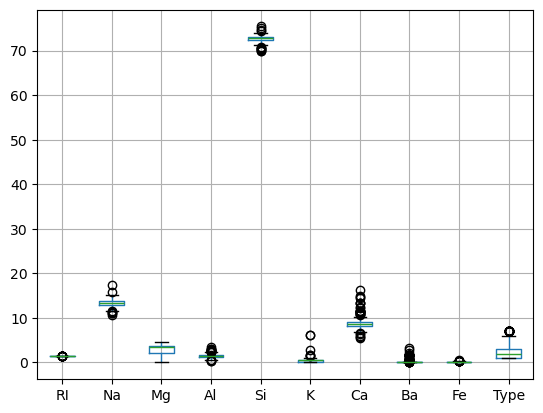

In [69]:
## Outlier checking
df.boxplot()
plt.show()

In [70]:
def outlier_capping(df,columns):
    Q1= df[columns].quantile(0.25)
    Q3 = df[columns].quantile(0.75)
    IQR = Q3 -Q1
    lower_extreme = Q1 - 1.5*IQR
    upper_extreme = Q3 + 1.5*IQR
    df[columns] = df[columns].apply(lambda x:lower_extreme if x<lower_extreme else
                                    upper_extreme if x> upper_extreme else x)
for col in df.select_dtypes(include=['int','float']).columns:
    outlier_capping(df,col)

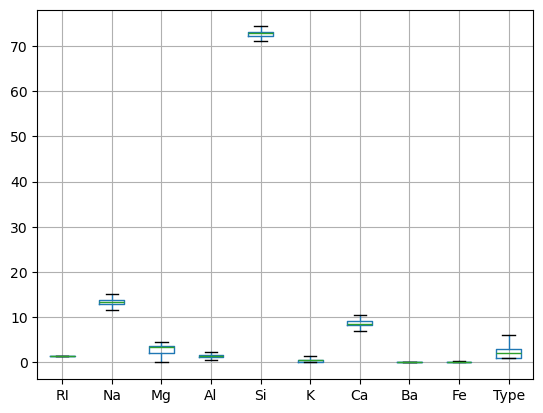

In [71]:
df.boxplot()
plt.show()

In [75]:
df['Ba'].unique()

array([0.])

In [72]:
target = df['Type']
features = df.drop(columns=['Type'])

In [74]:
from sklearn.feature_selection import f_classif

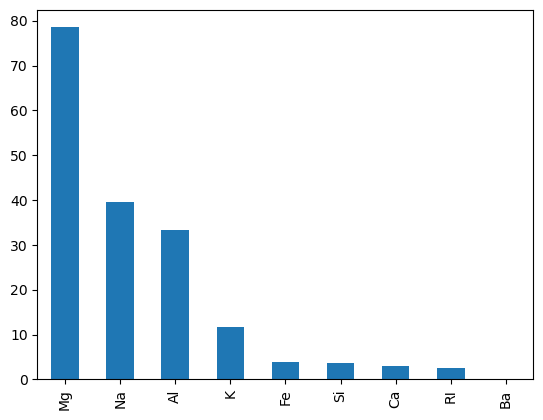

In [28]:
## Feature selection
f_class = f_classif(features,target)
pd.Series(f_class[0],index=features.columns).sort_values(ascending=False).plot(kind='bar')
plt.show()

In [76]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [77]:
vif = pd.DataFrame()
vif['features'] = features.columns
vif['VIF_score'] = [variance_inflation_factor(features.values,i)
                    for i in range(len(features.columns)) ]
vif

,features,VIF_score
0,RI,25573.208052
1,Na,852.285666
2,Mg,12.053818
3,Al,24.688048
4,Si,16363.447473
5,K,8.588862
6,Ca,370.656737
7,Ba,NaN
8,Fe,1.505587


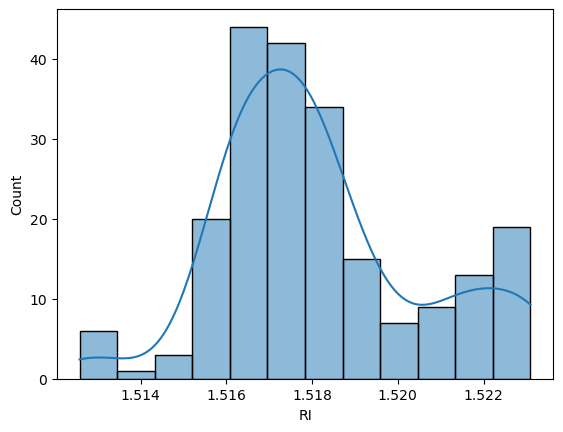

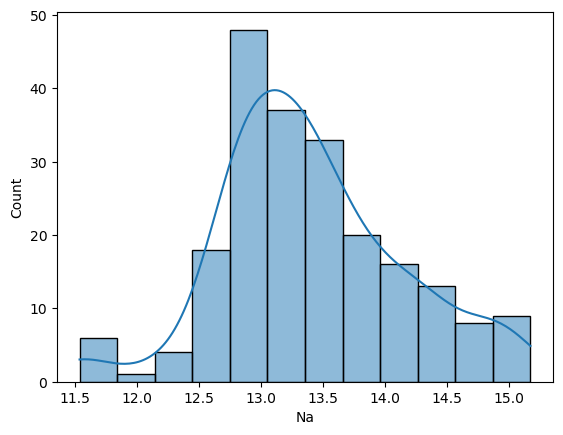

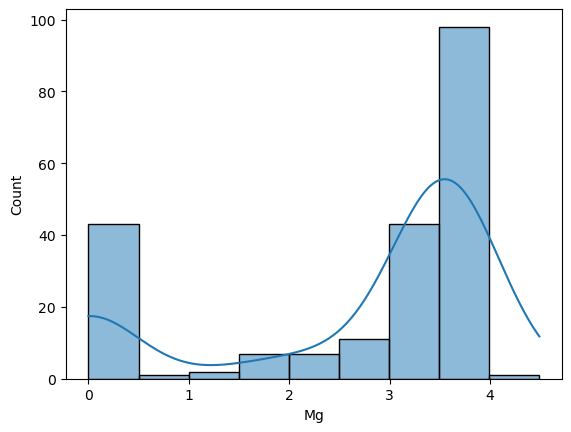

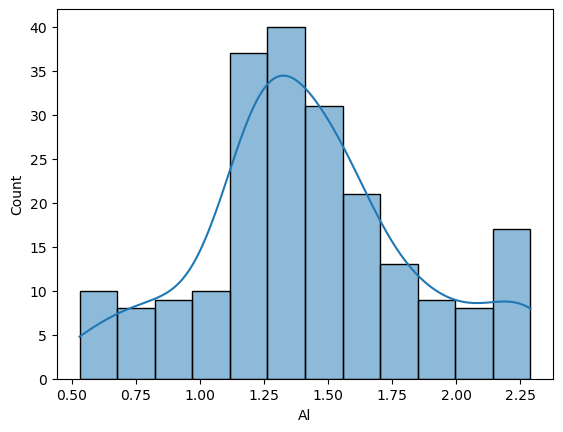

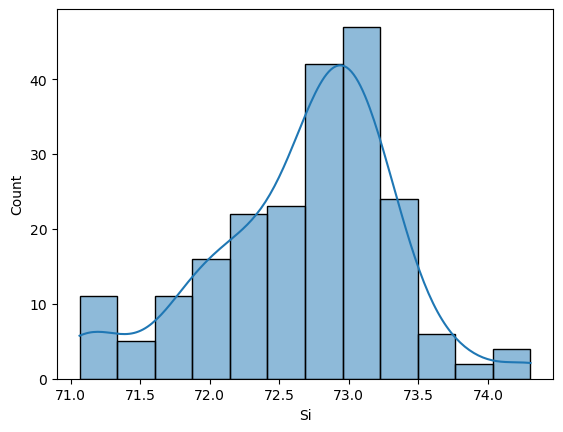

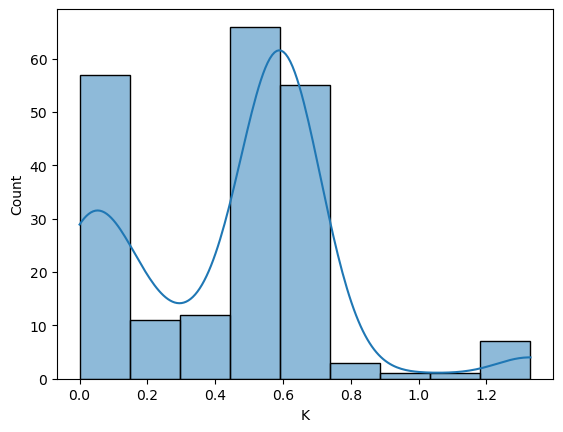

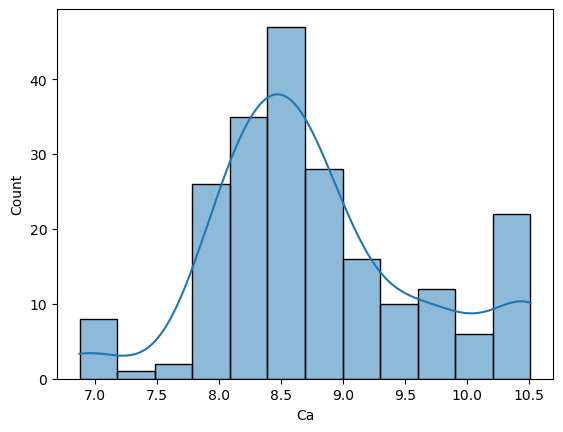

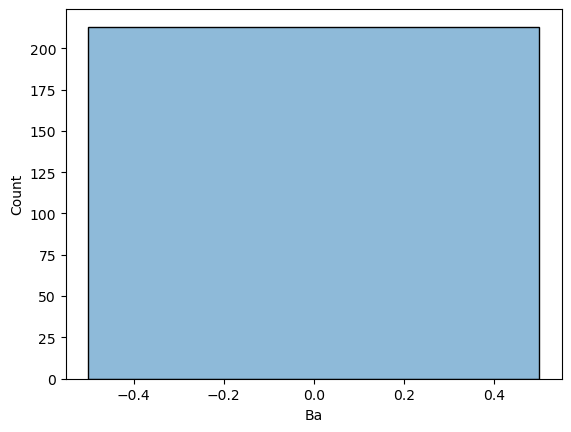

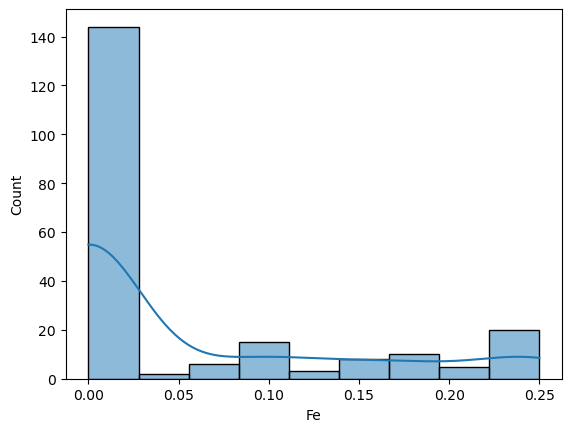

In [96]:
for col in features.columns:
    sns.histplot(features[col],kde='True')
    plt.show()
    plt.close()

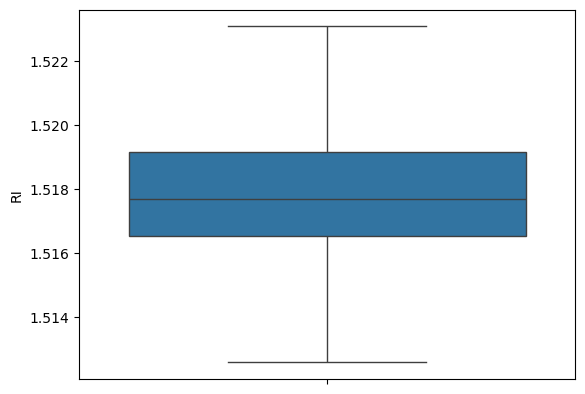

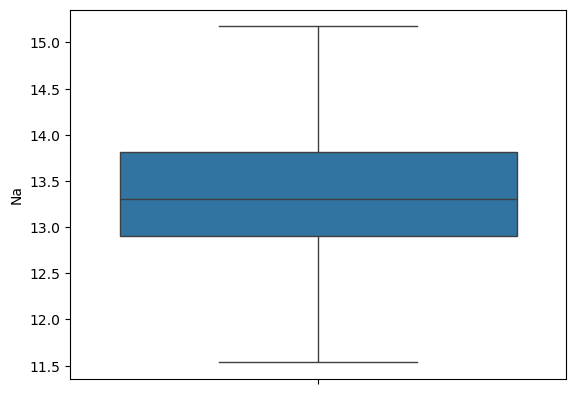

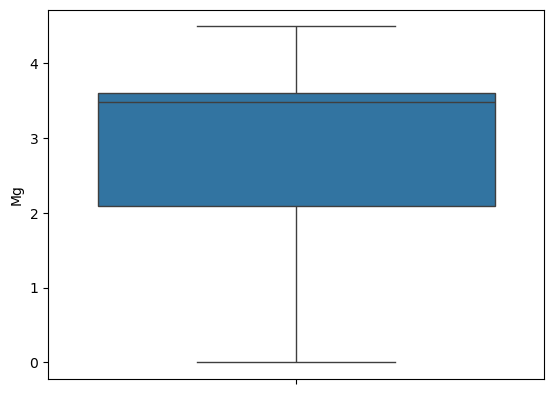

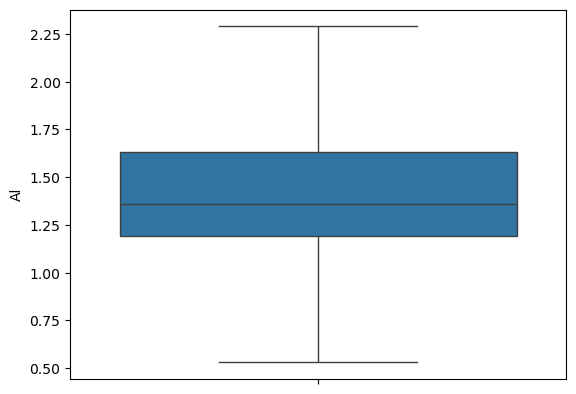

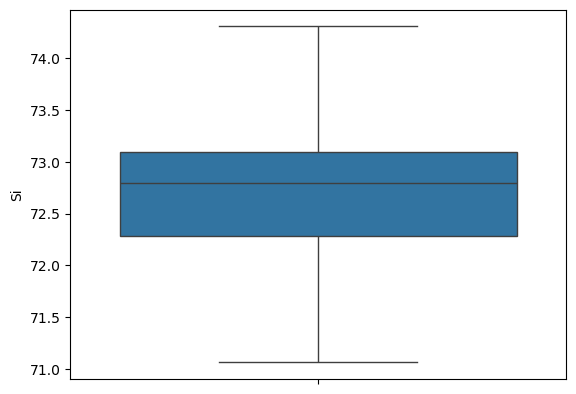

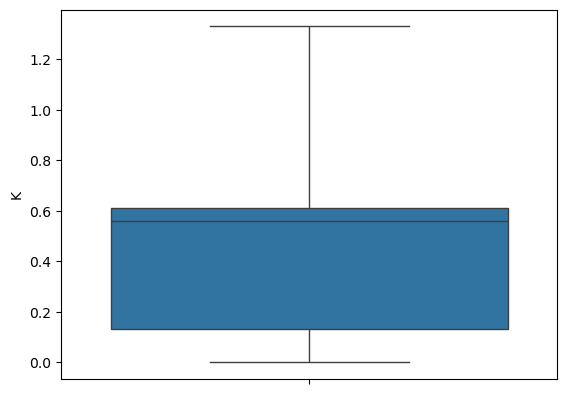

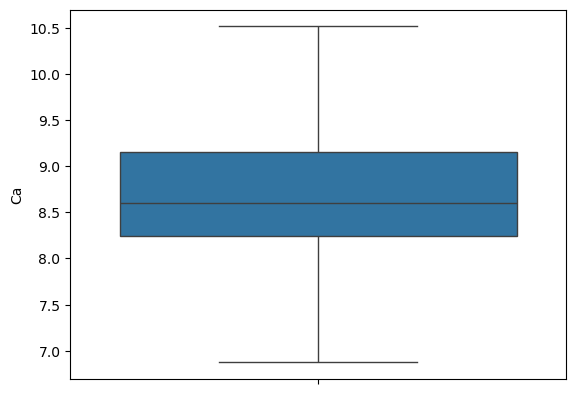

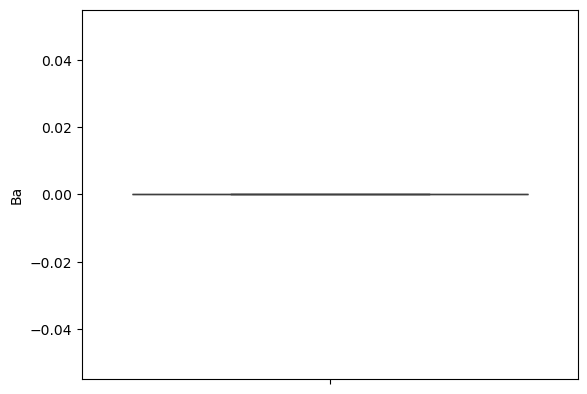

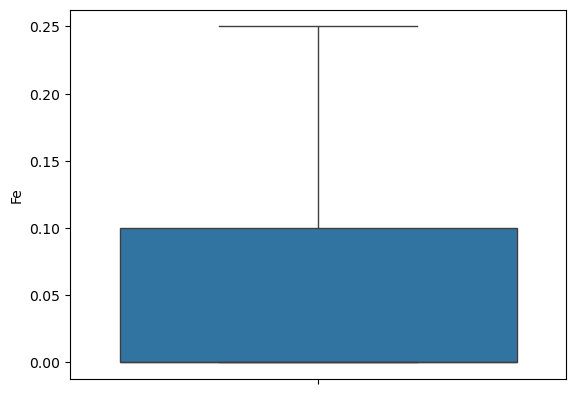

In [95]:
for col in features.columns:
    sns.boxplot(features[col])
    plt.show()
    plt.close()

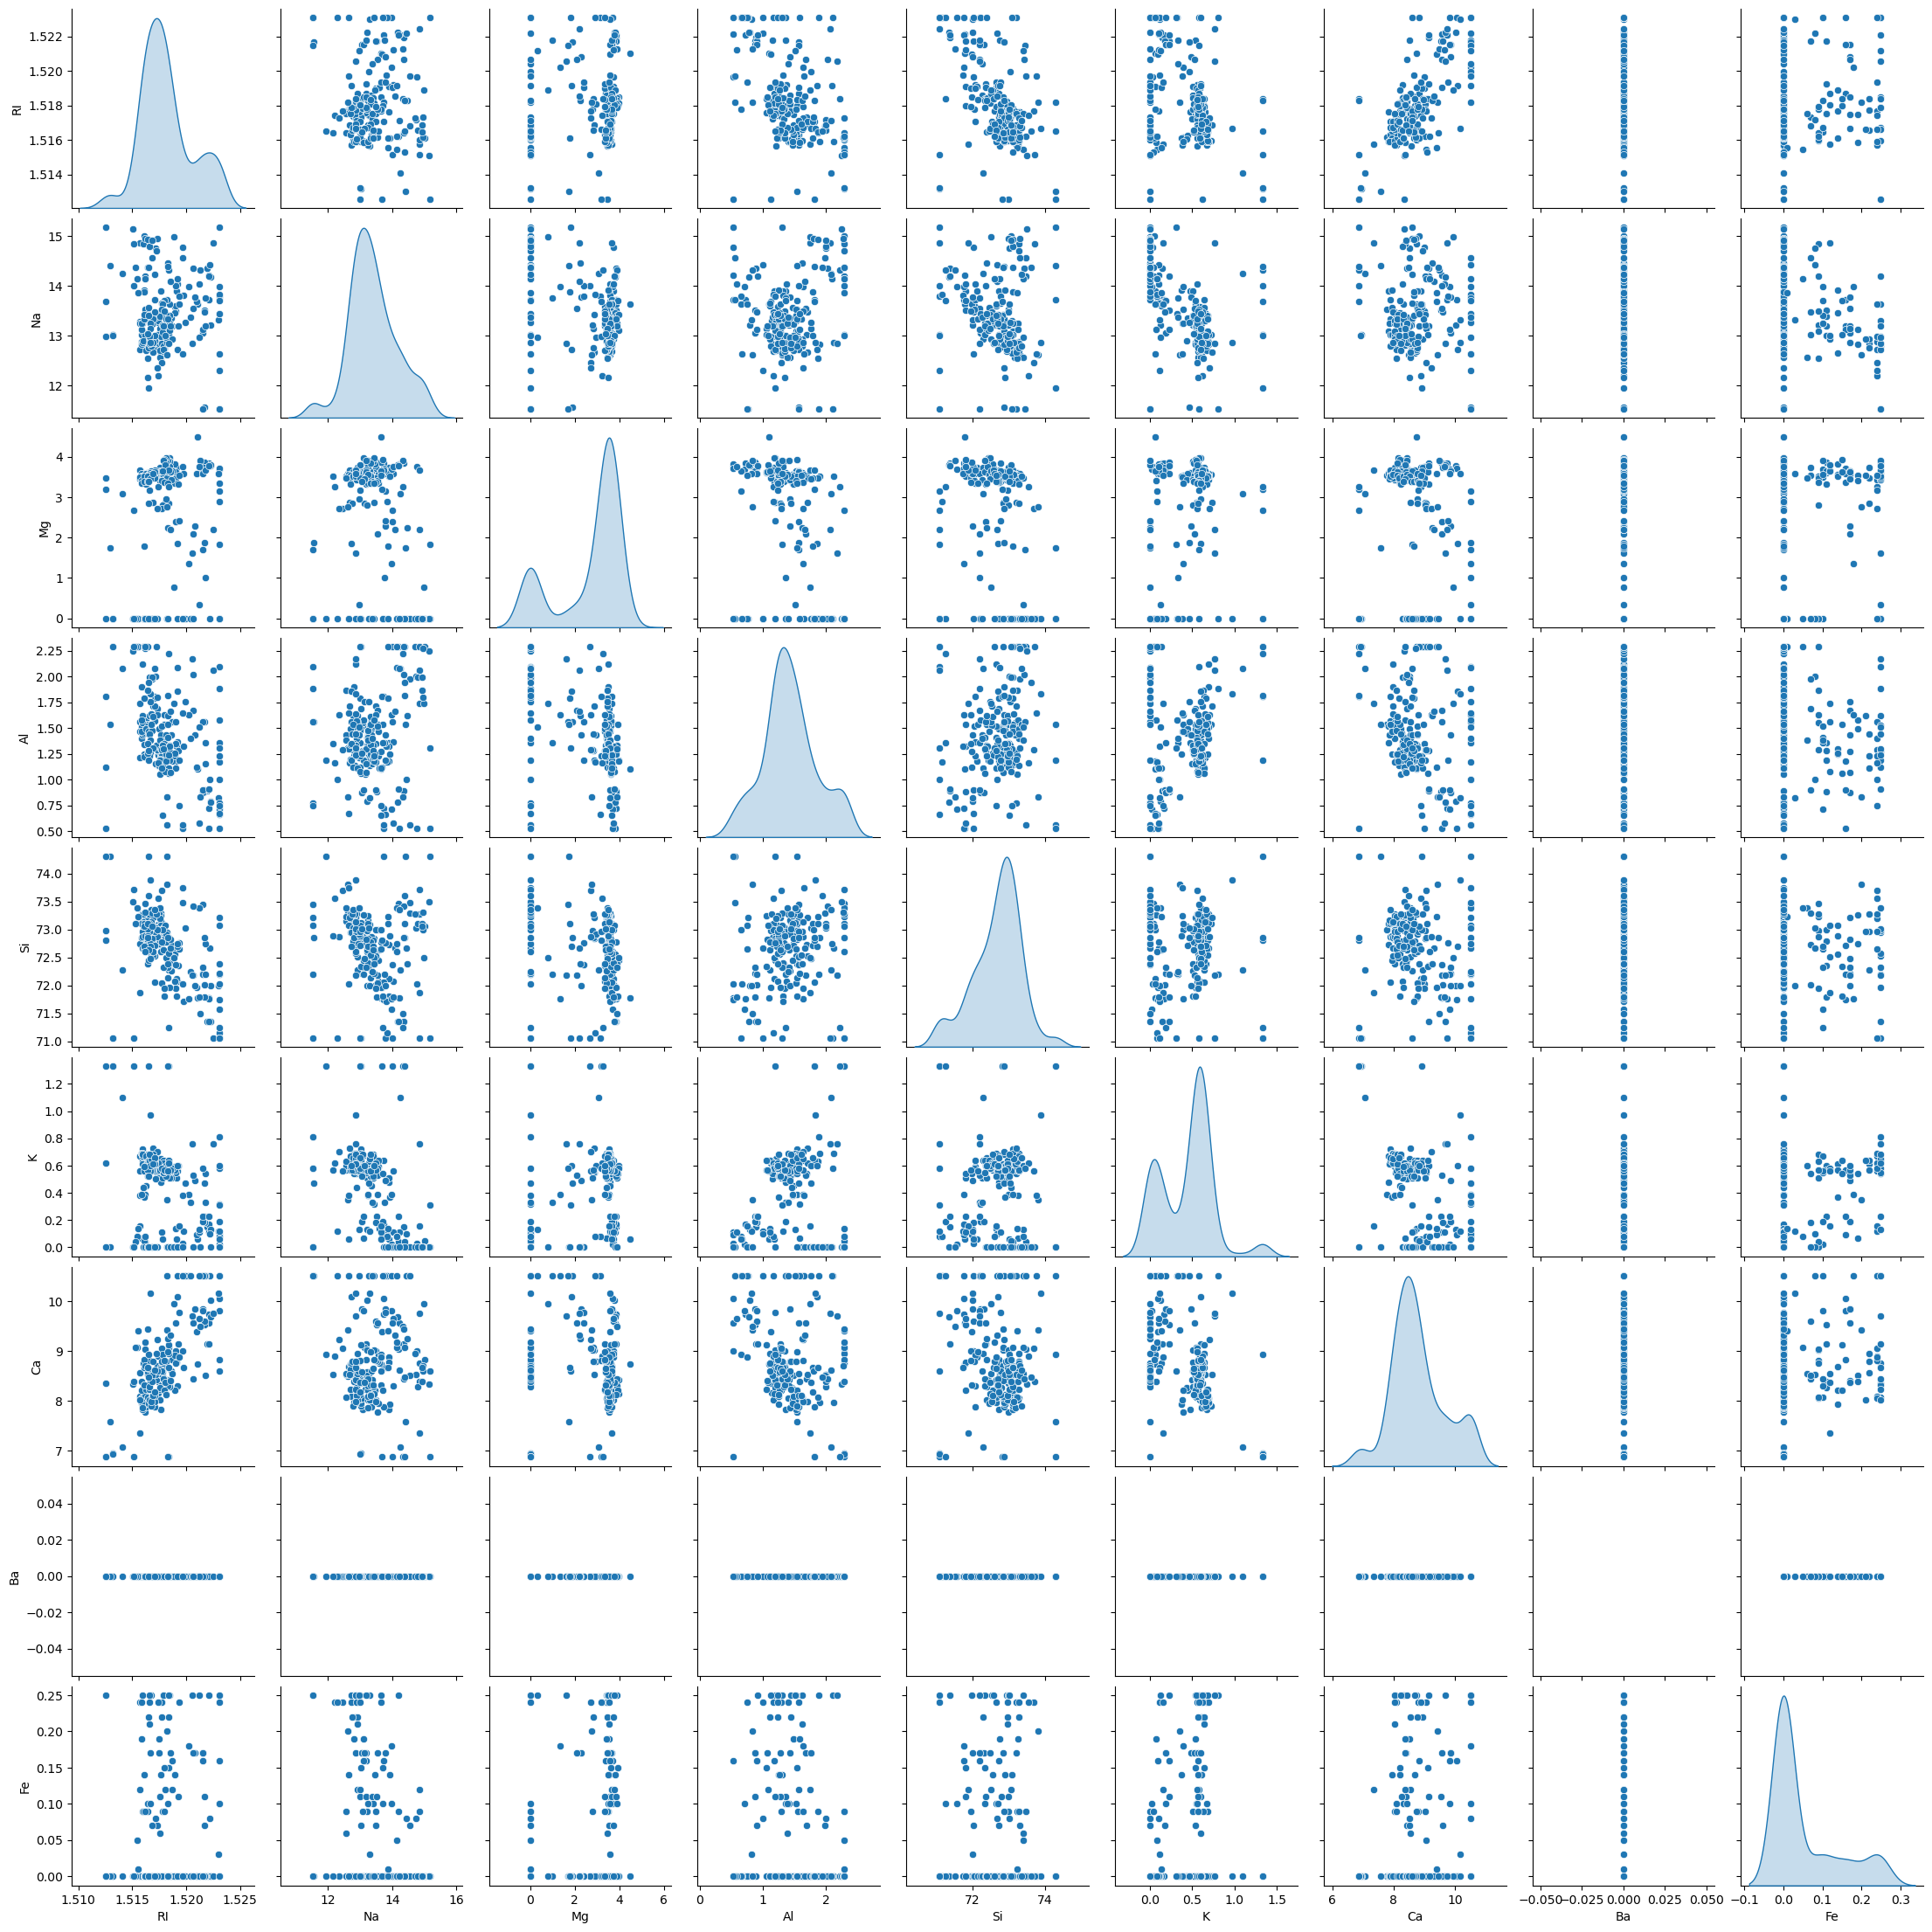

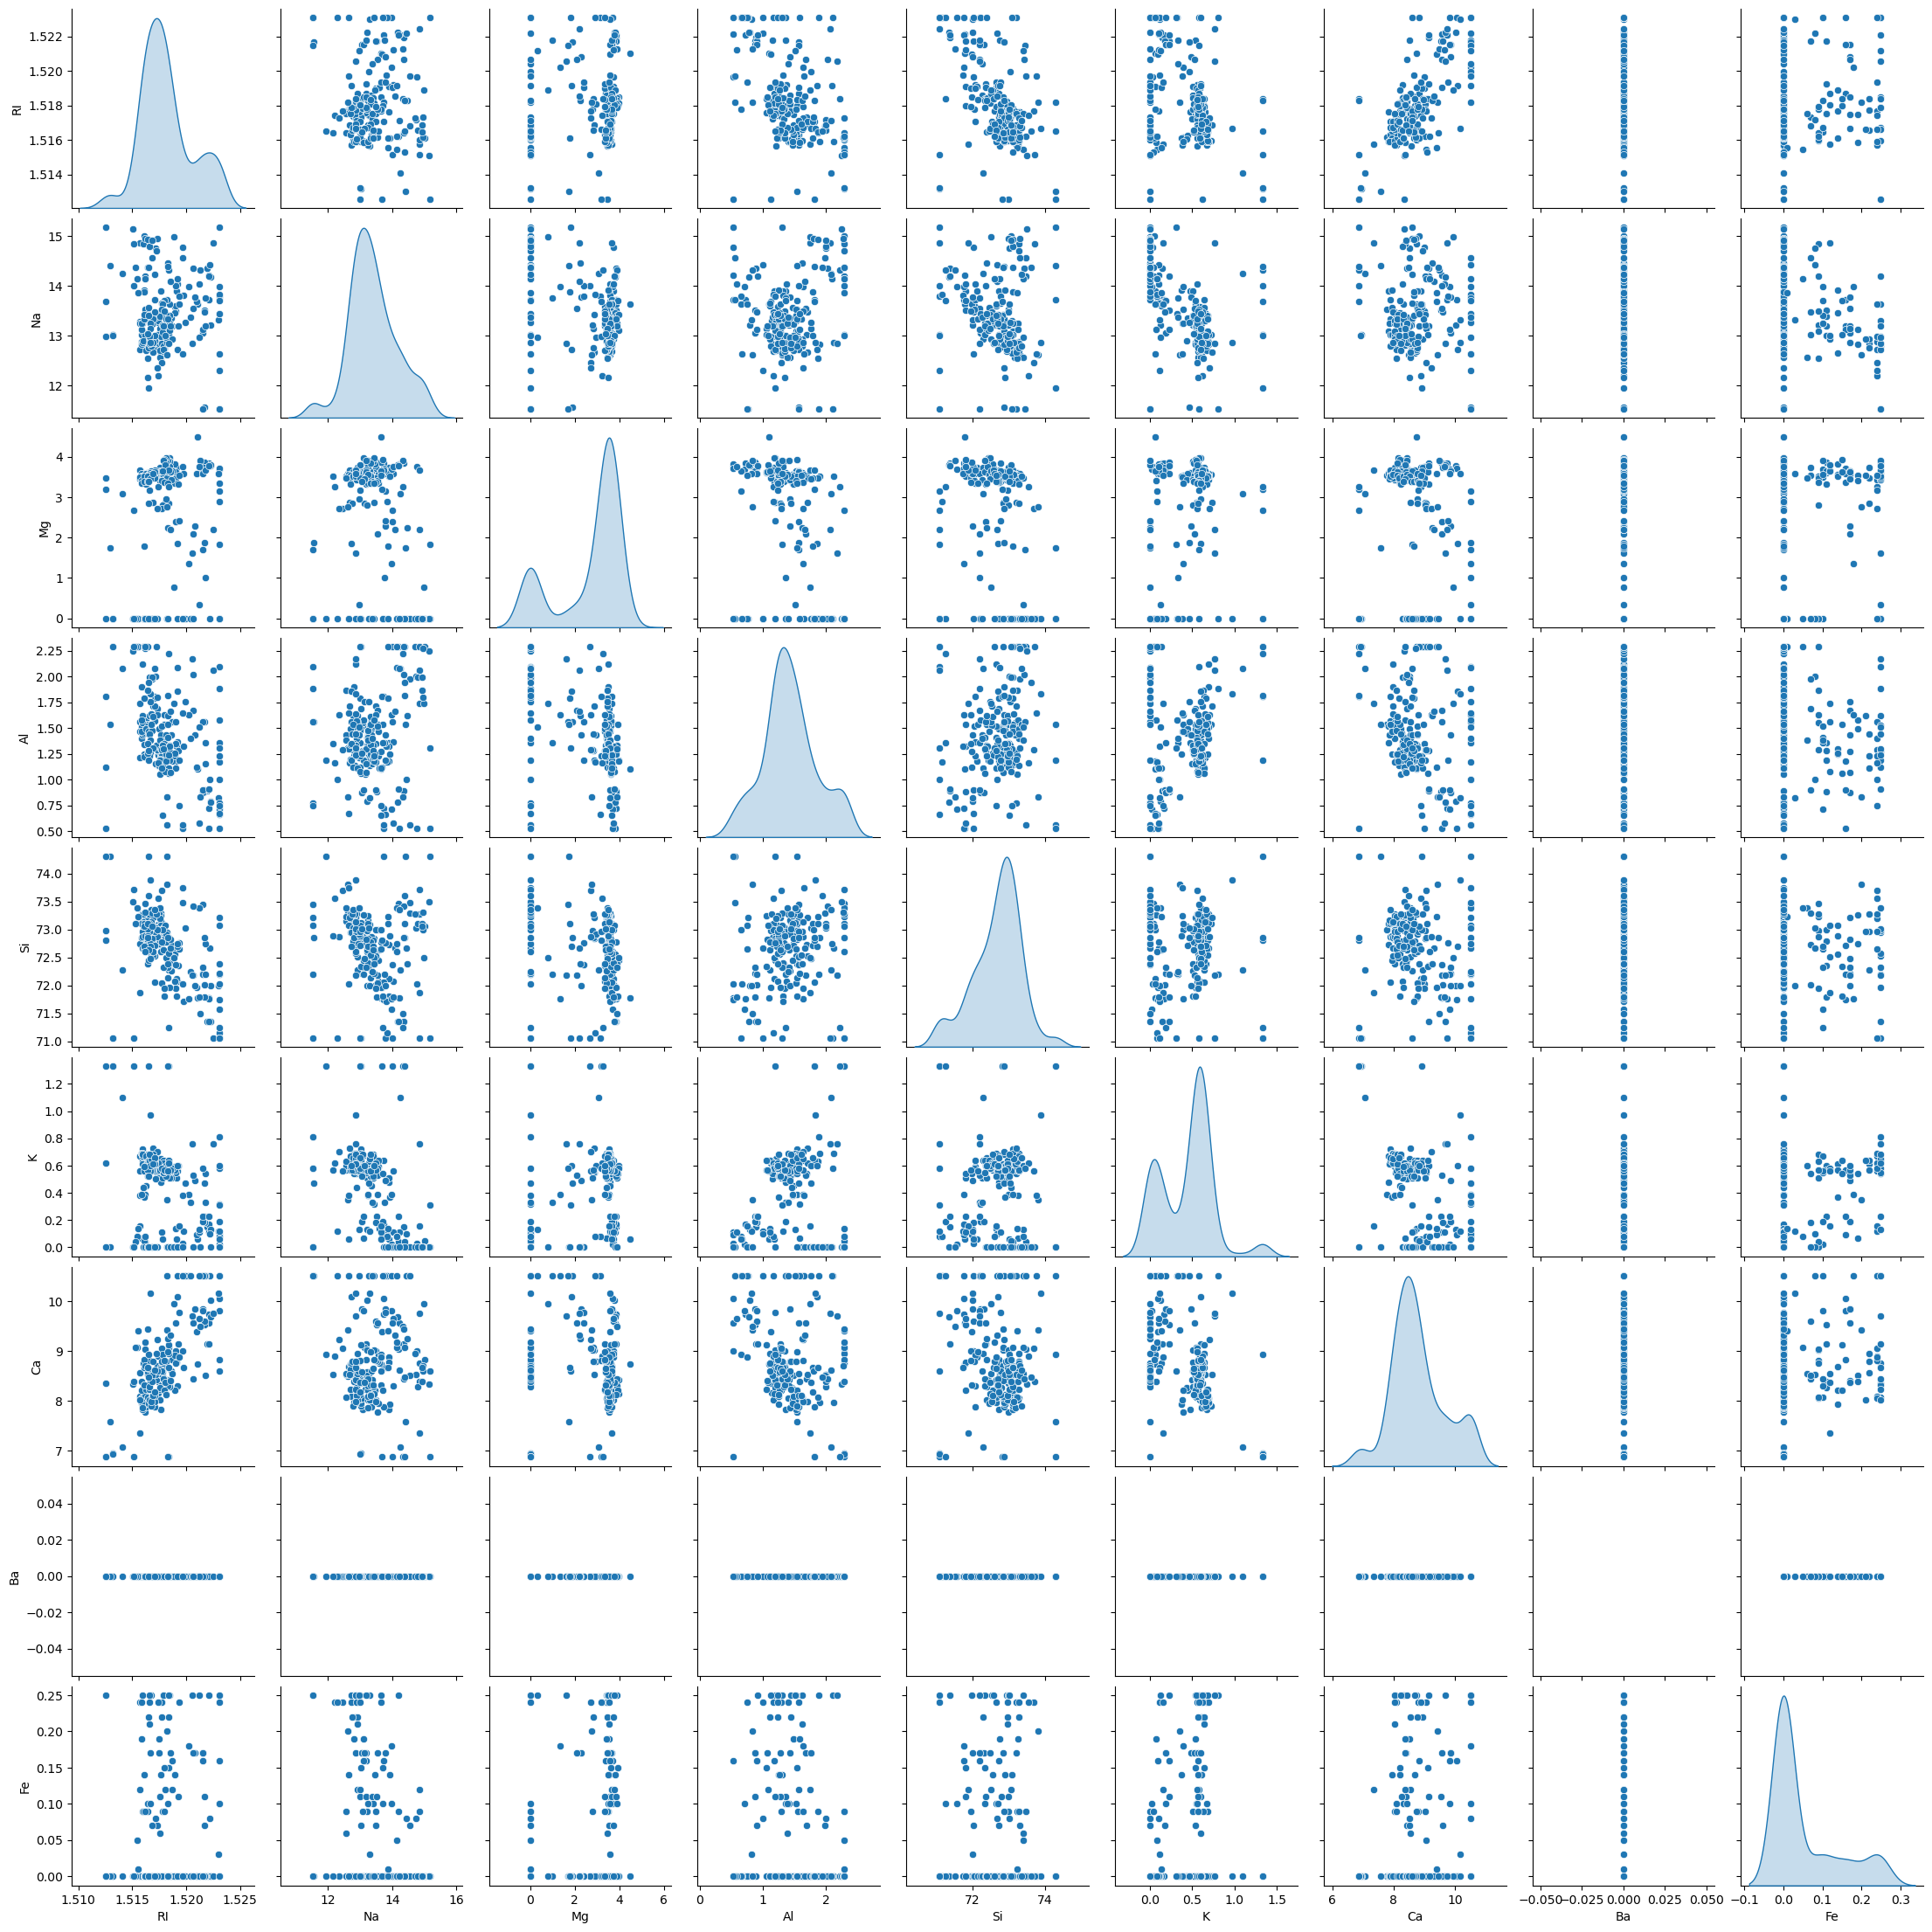

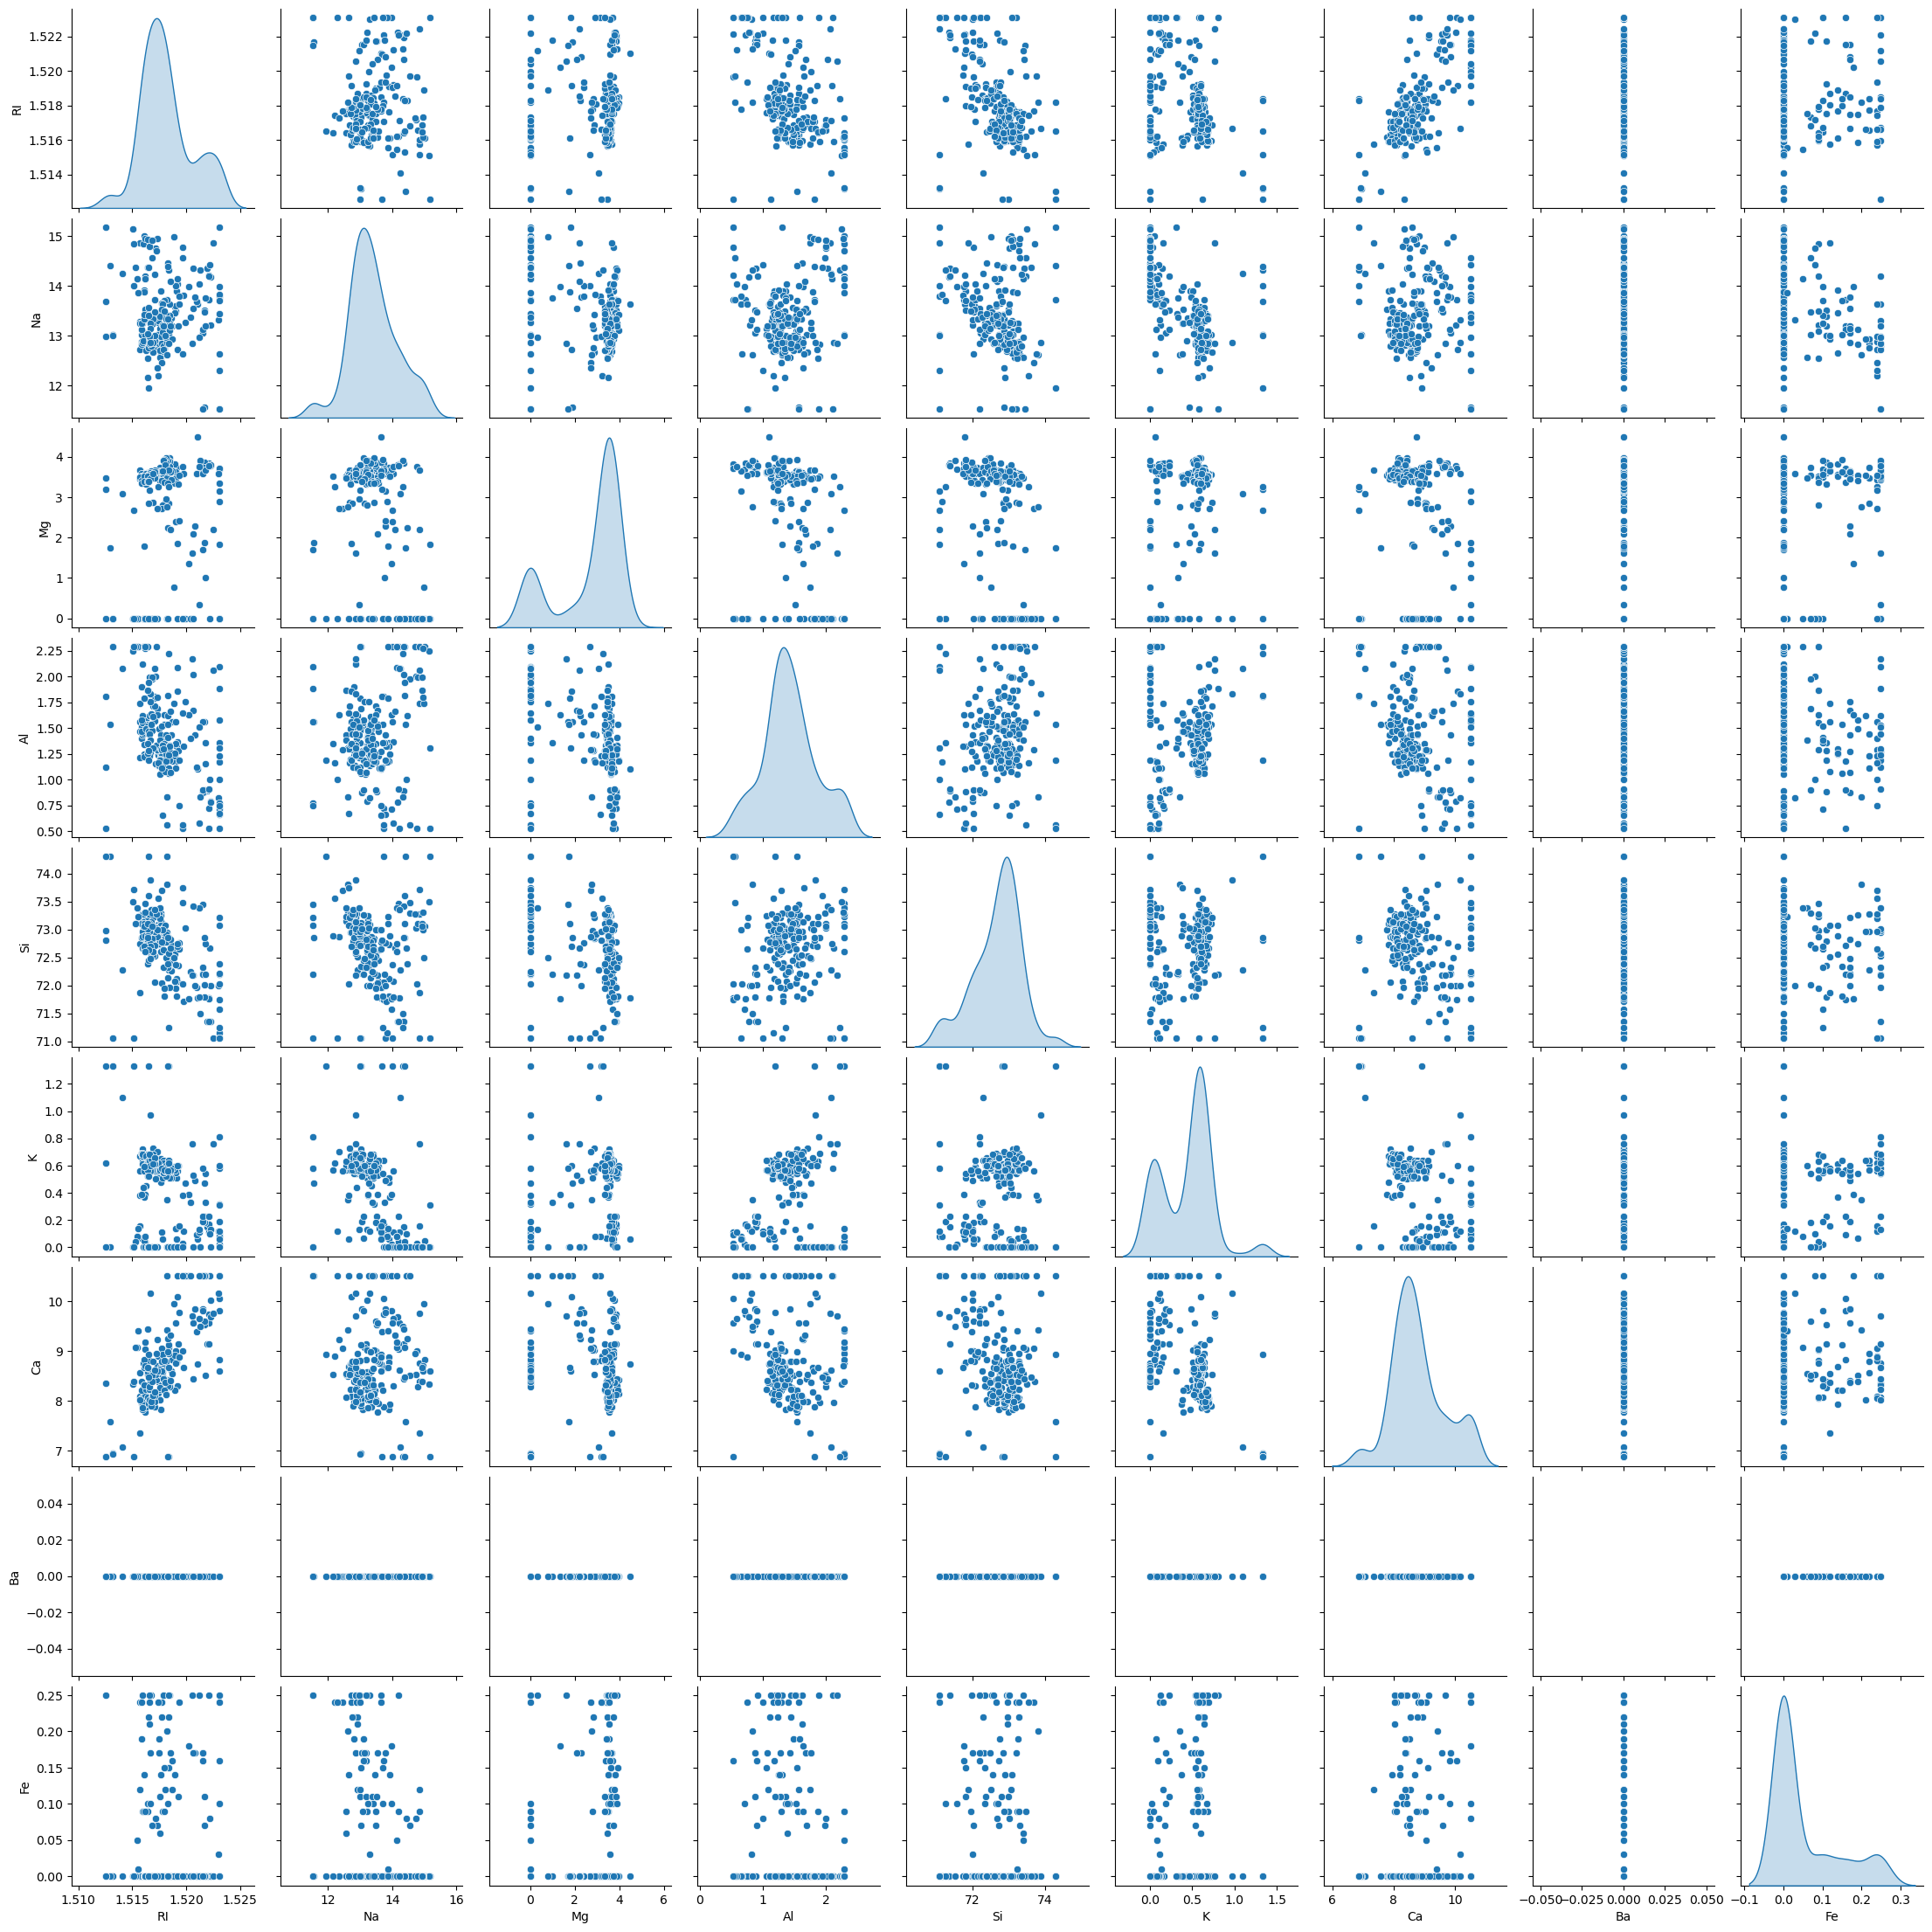

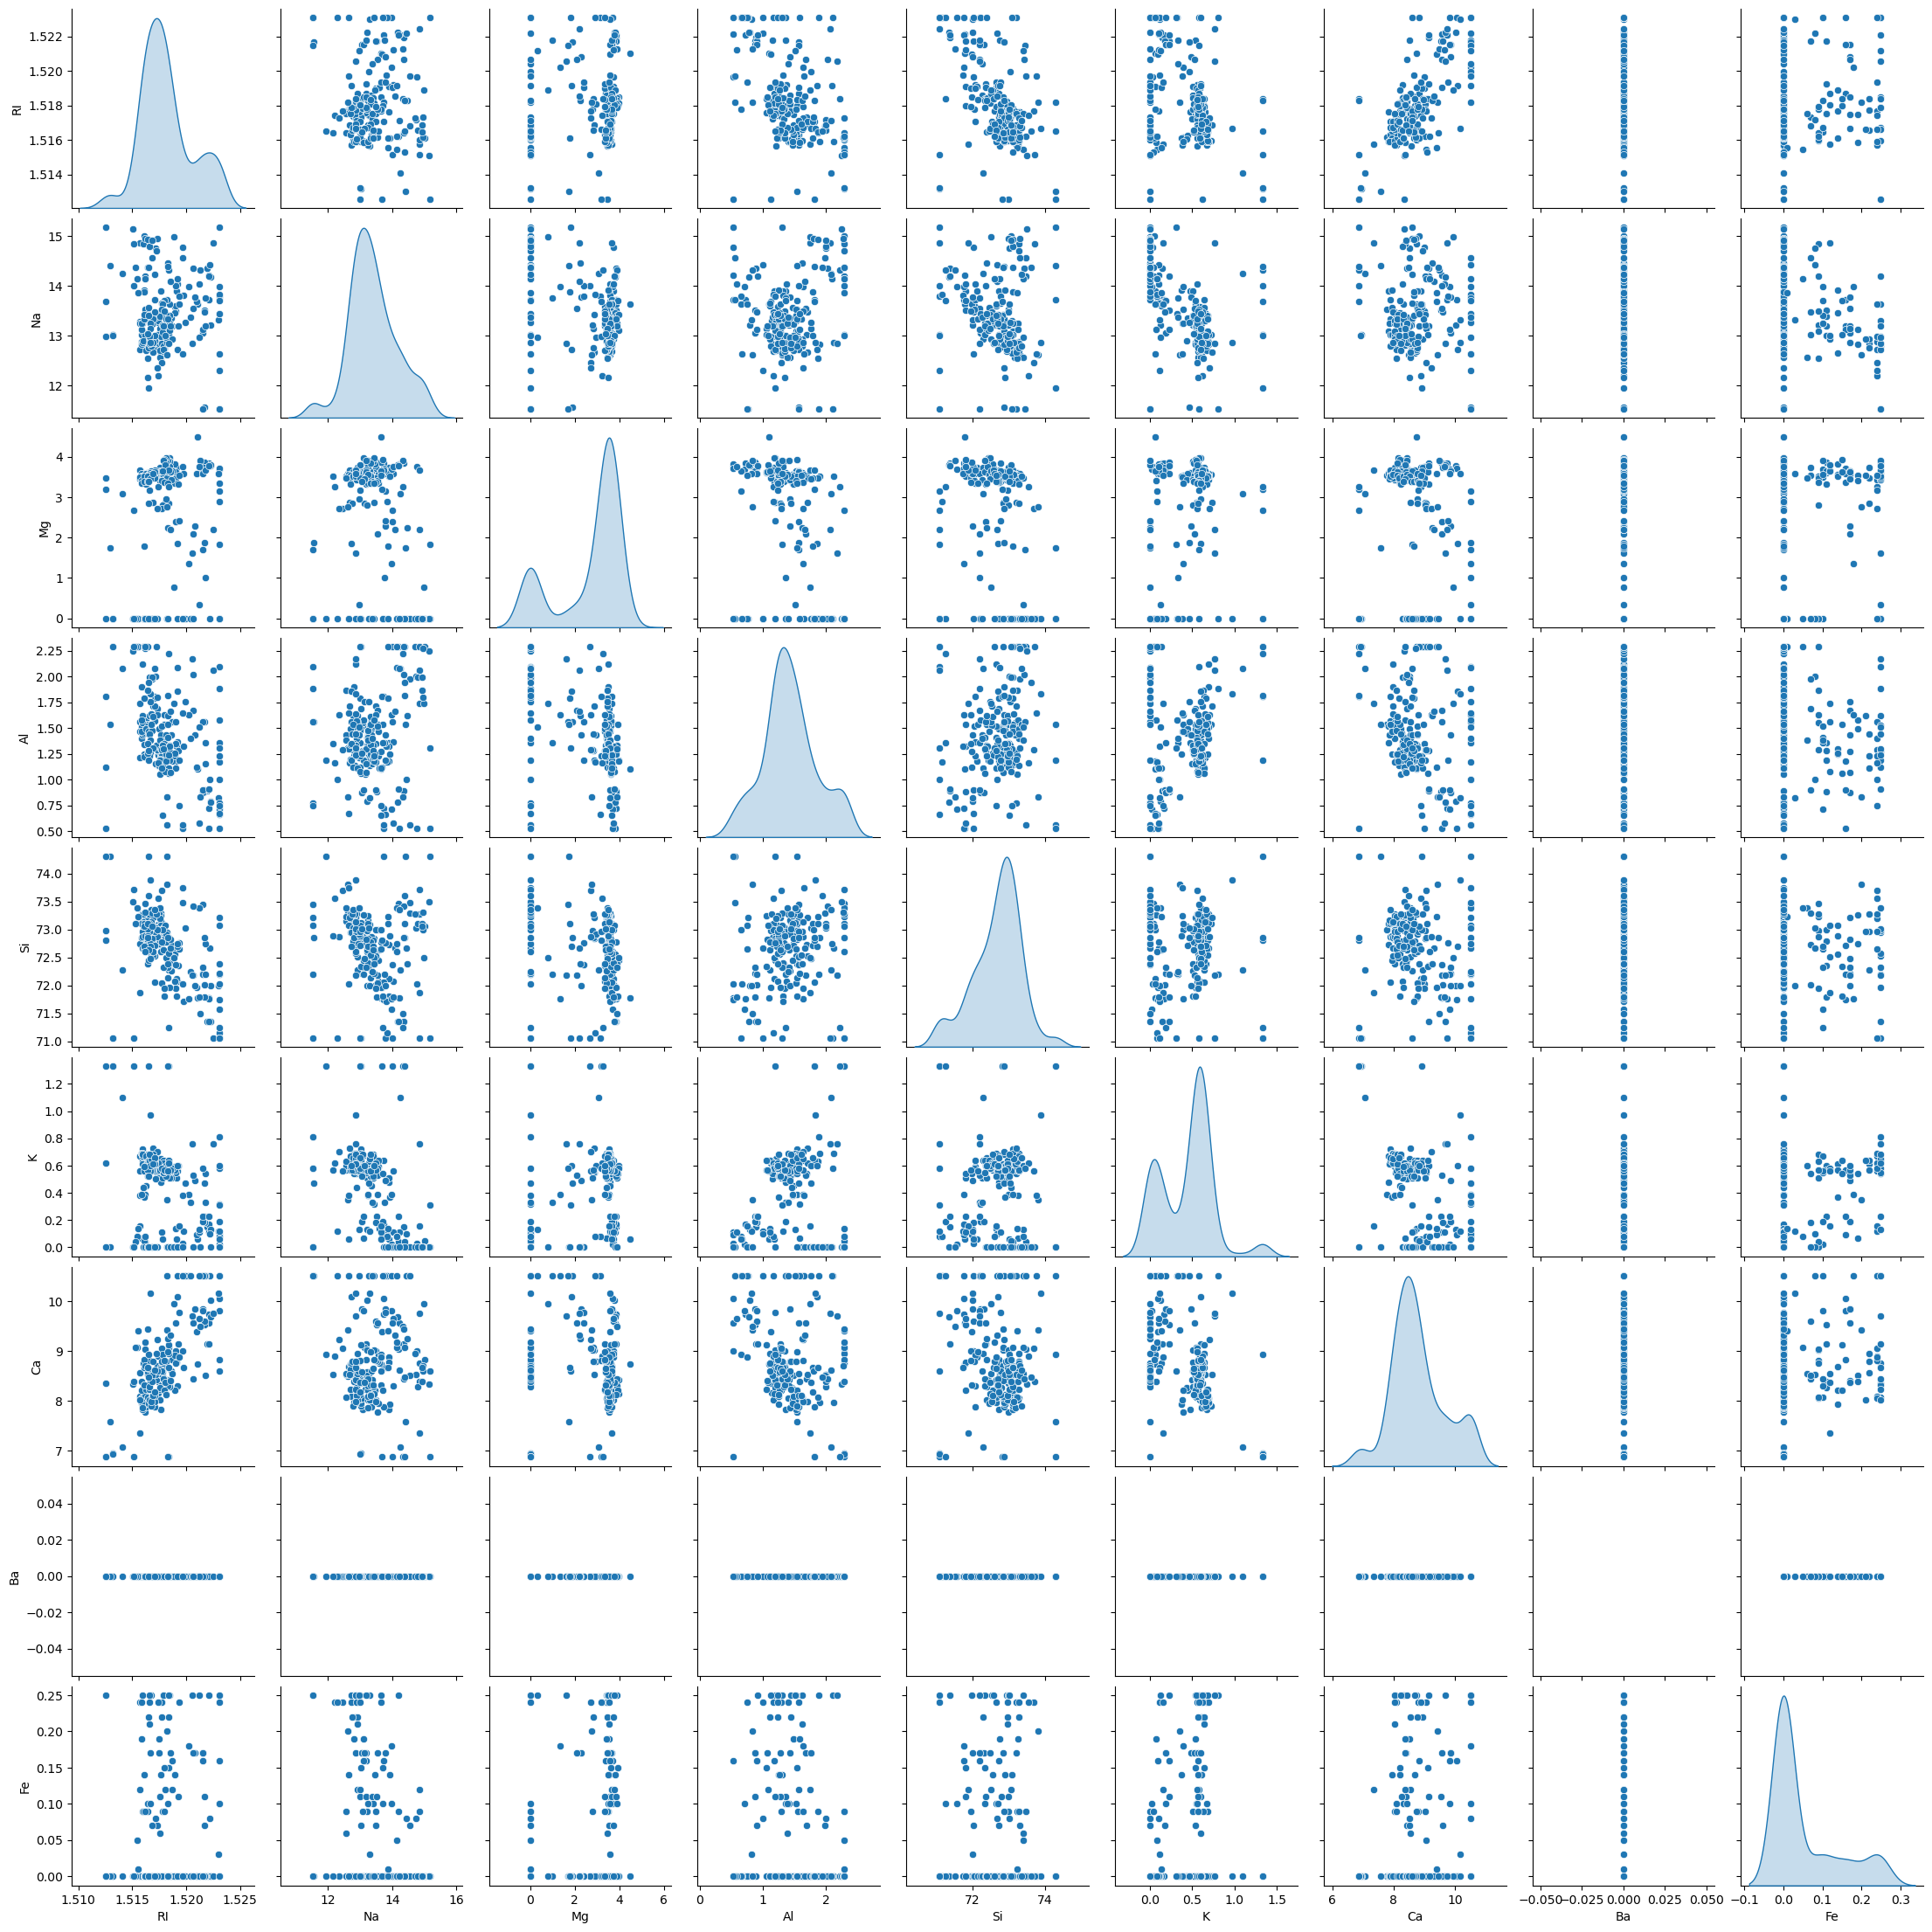

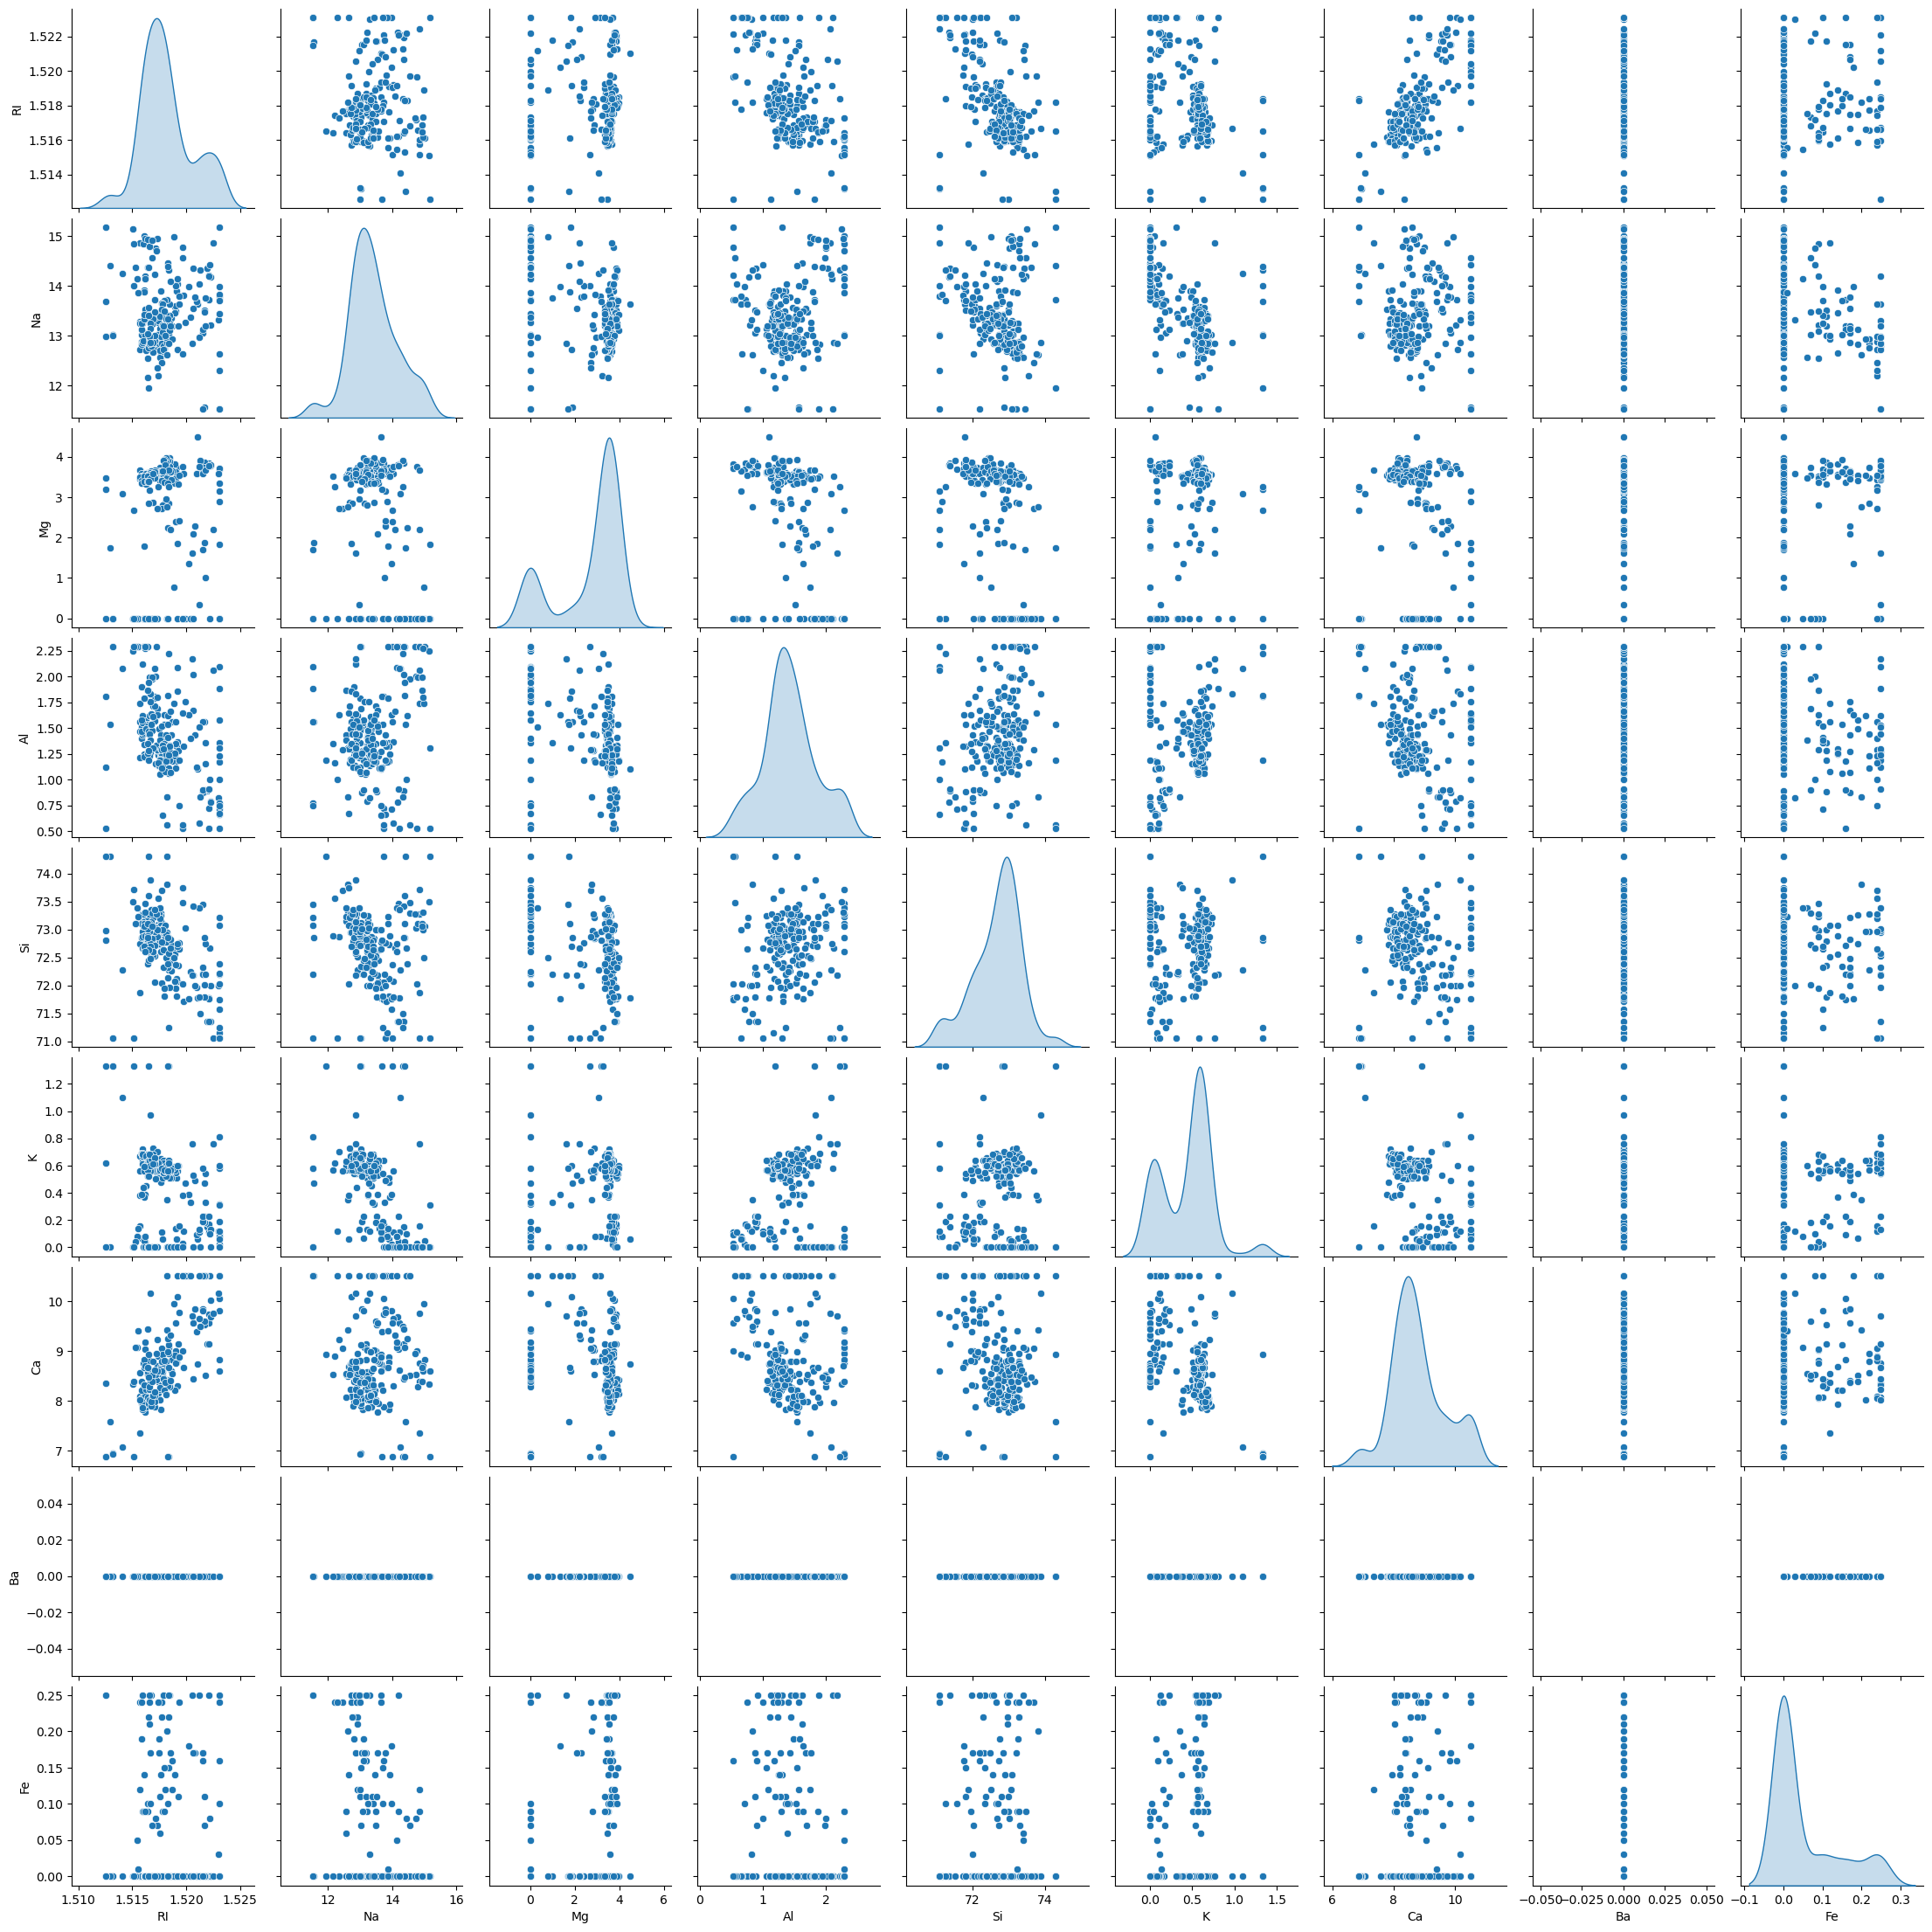

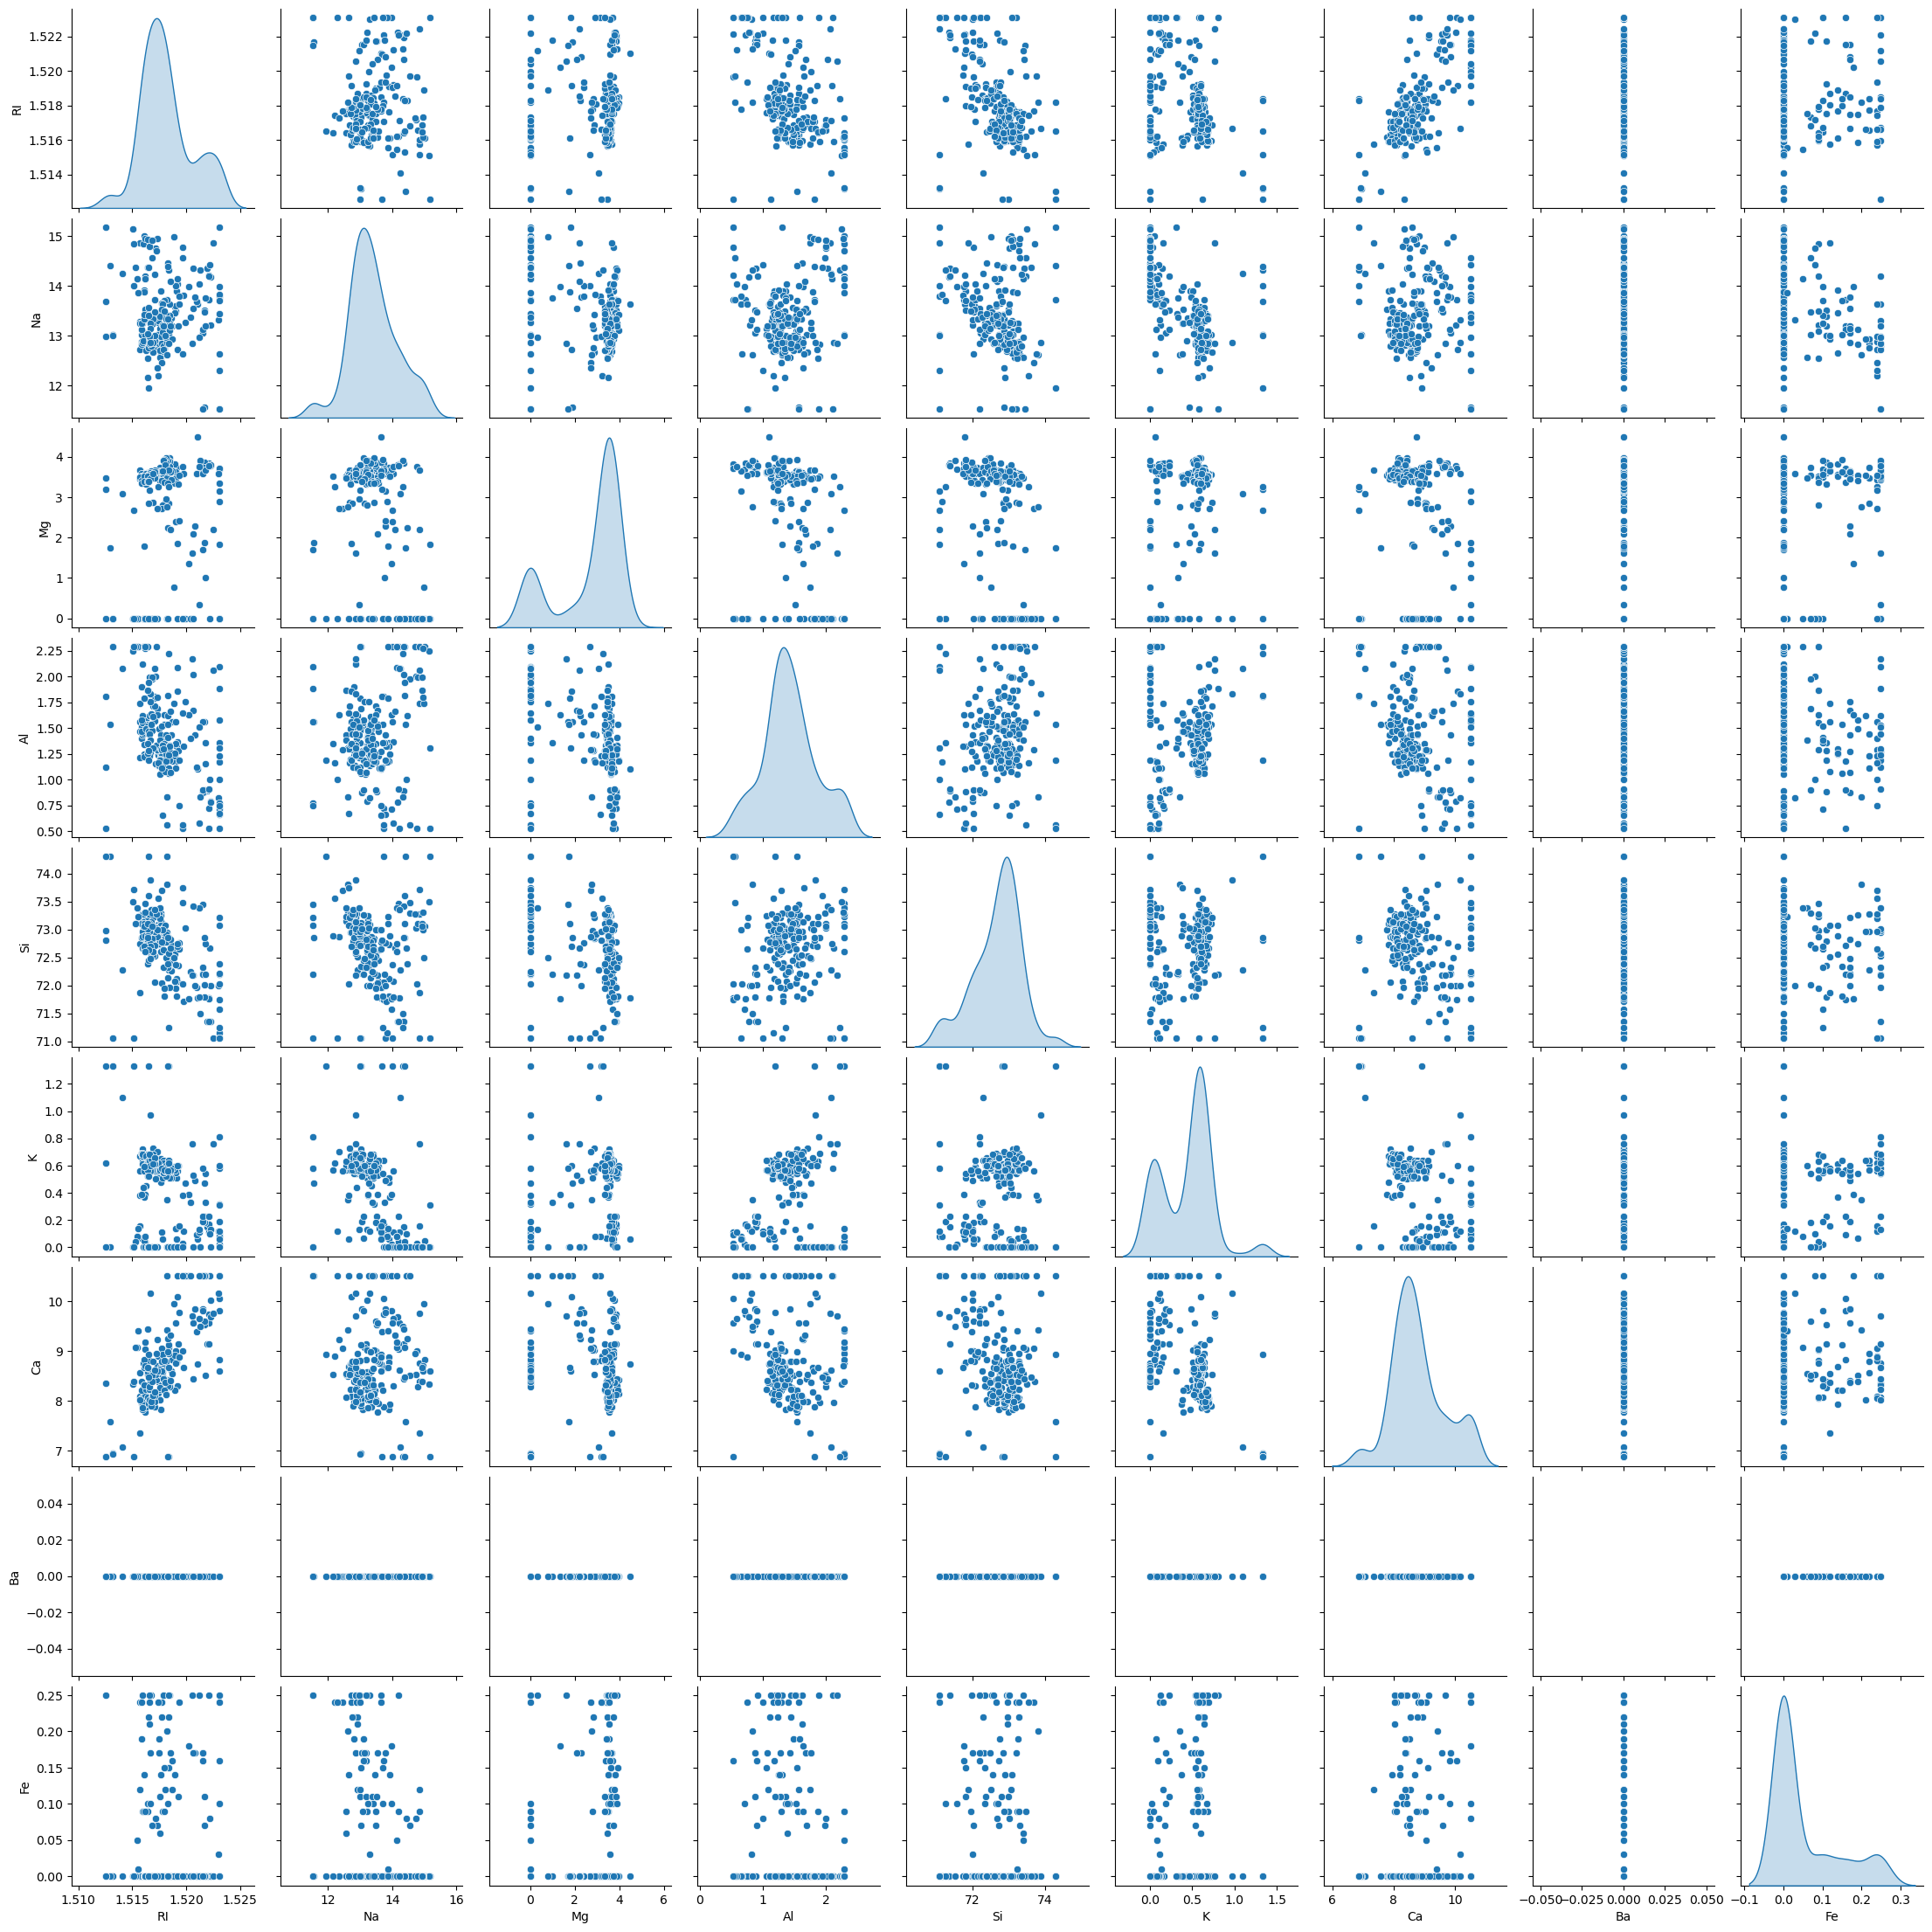

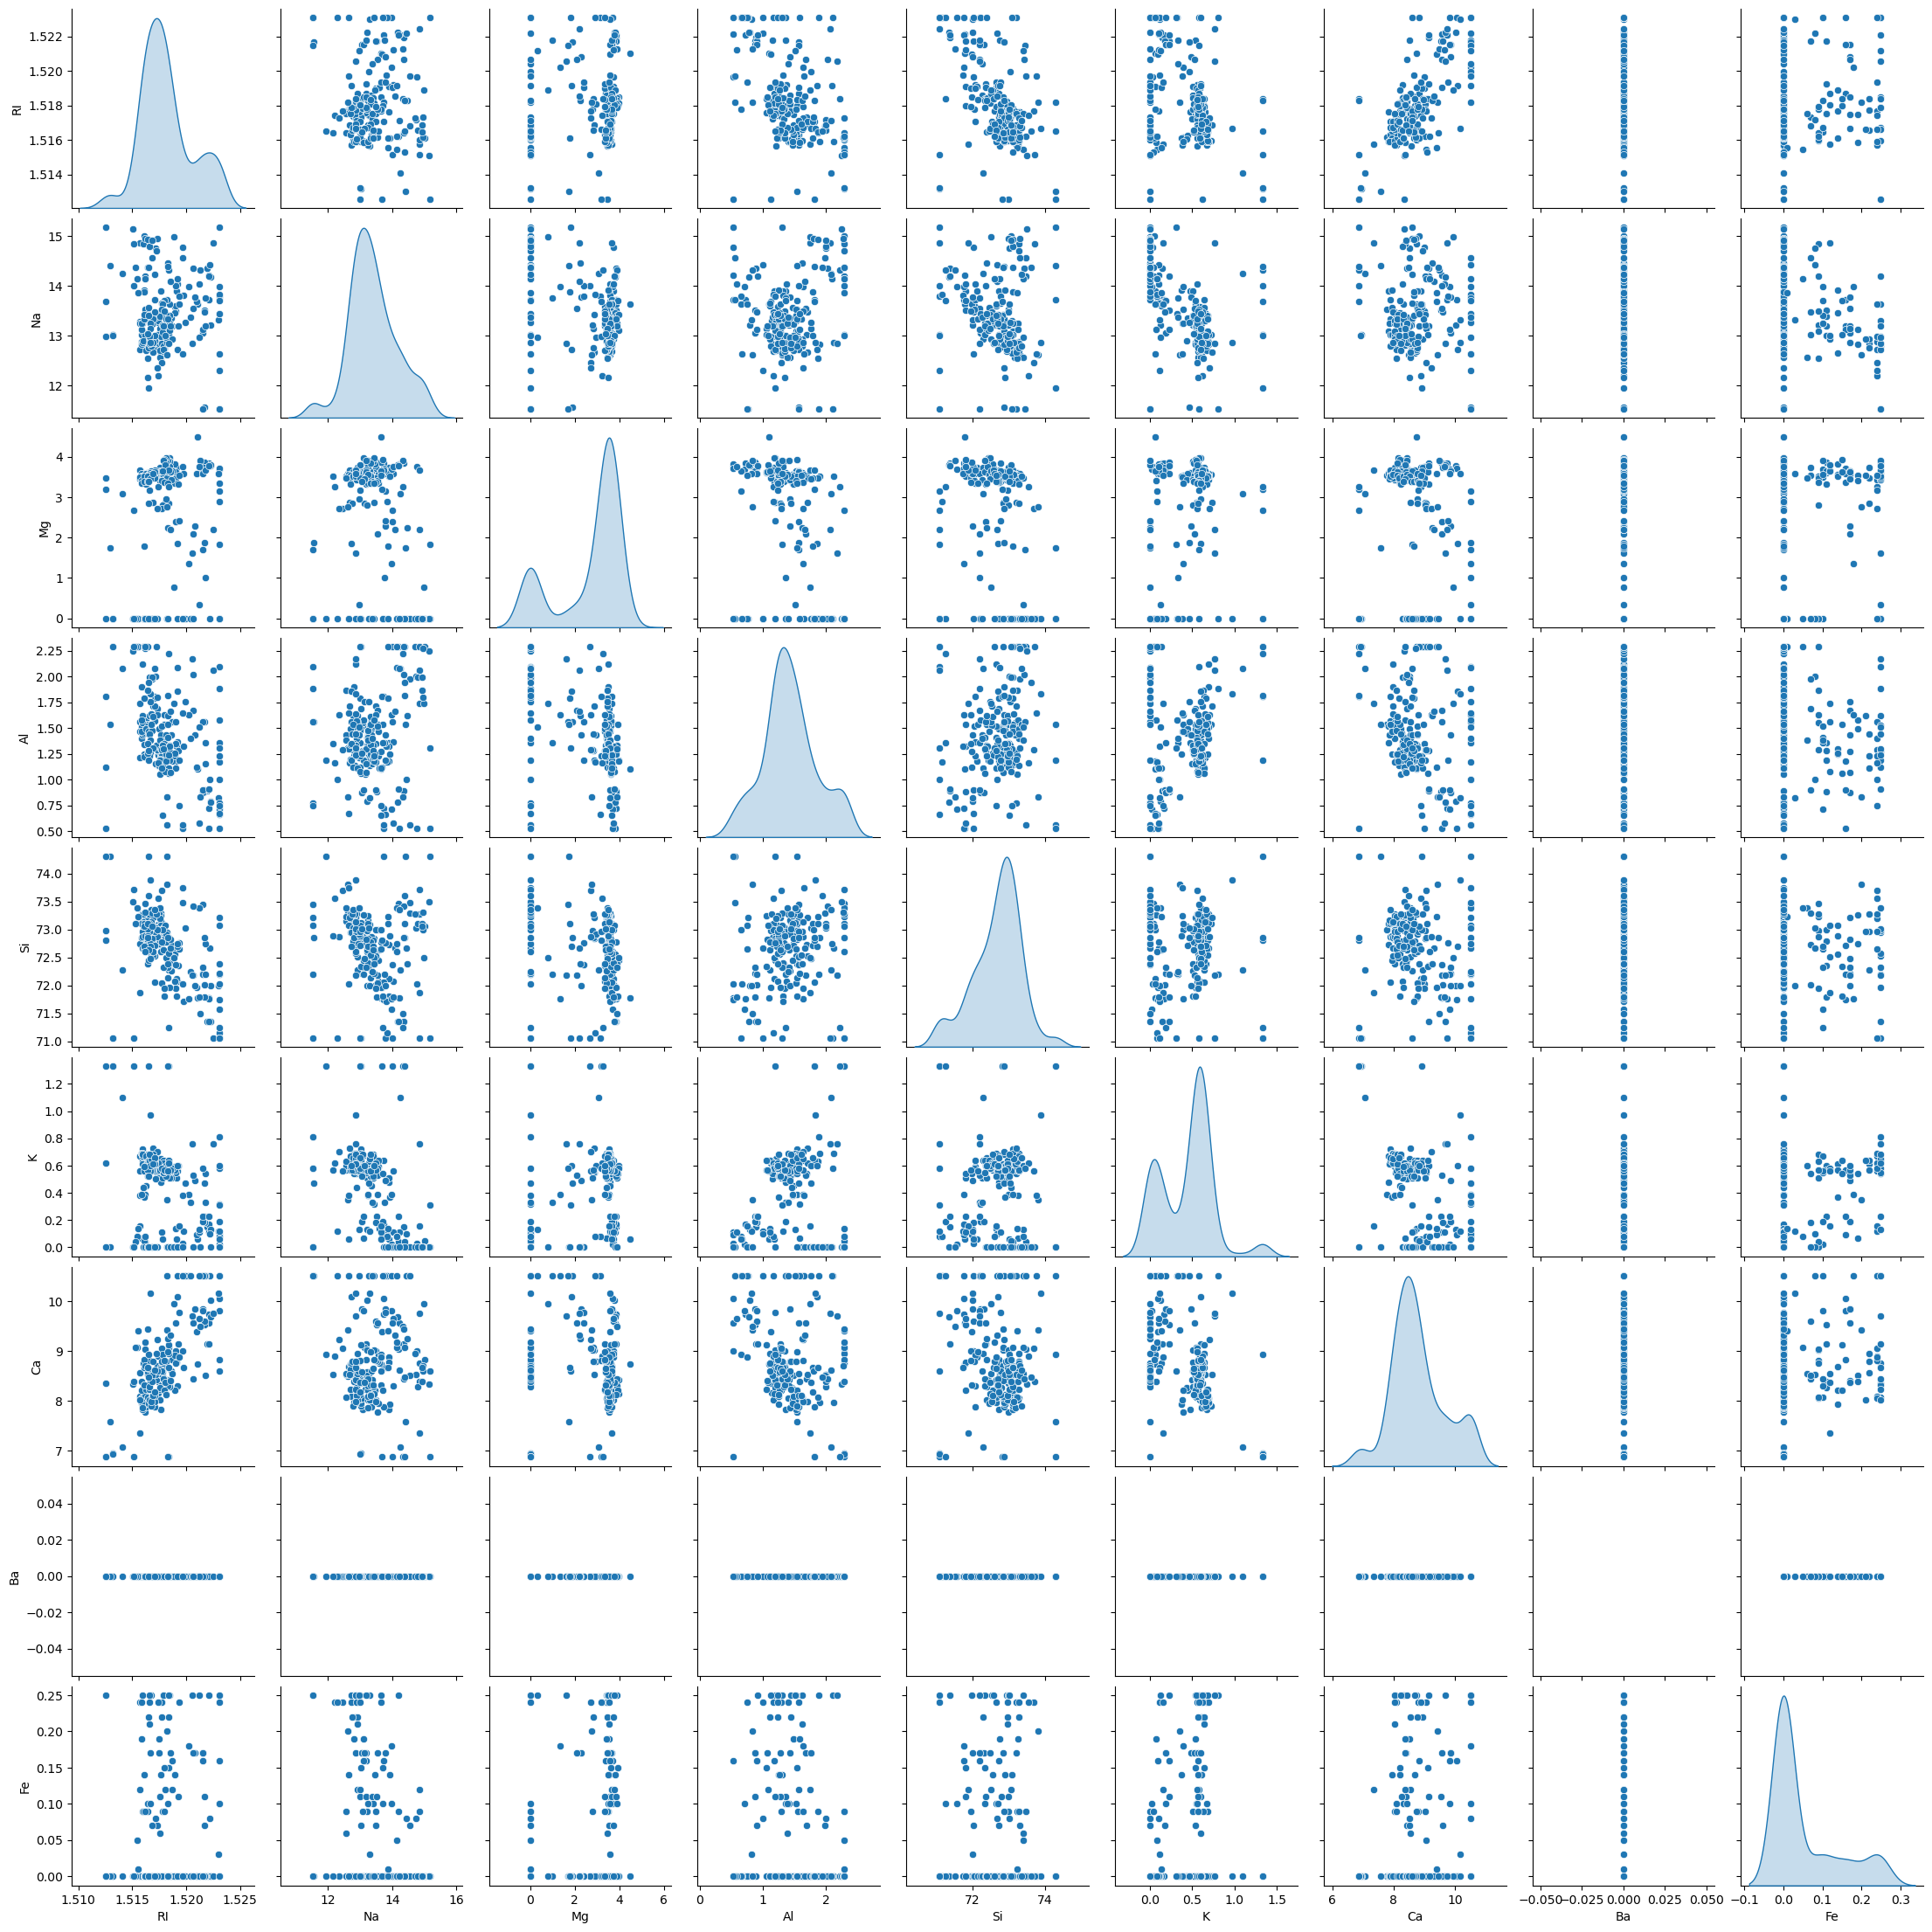

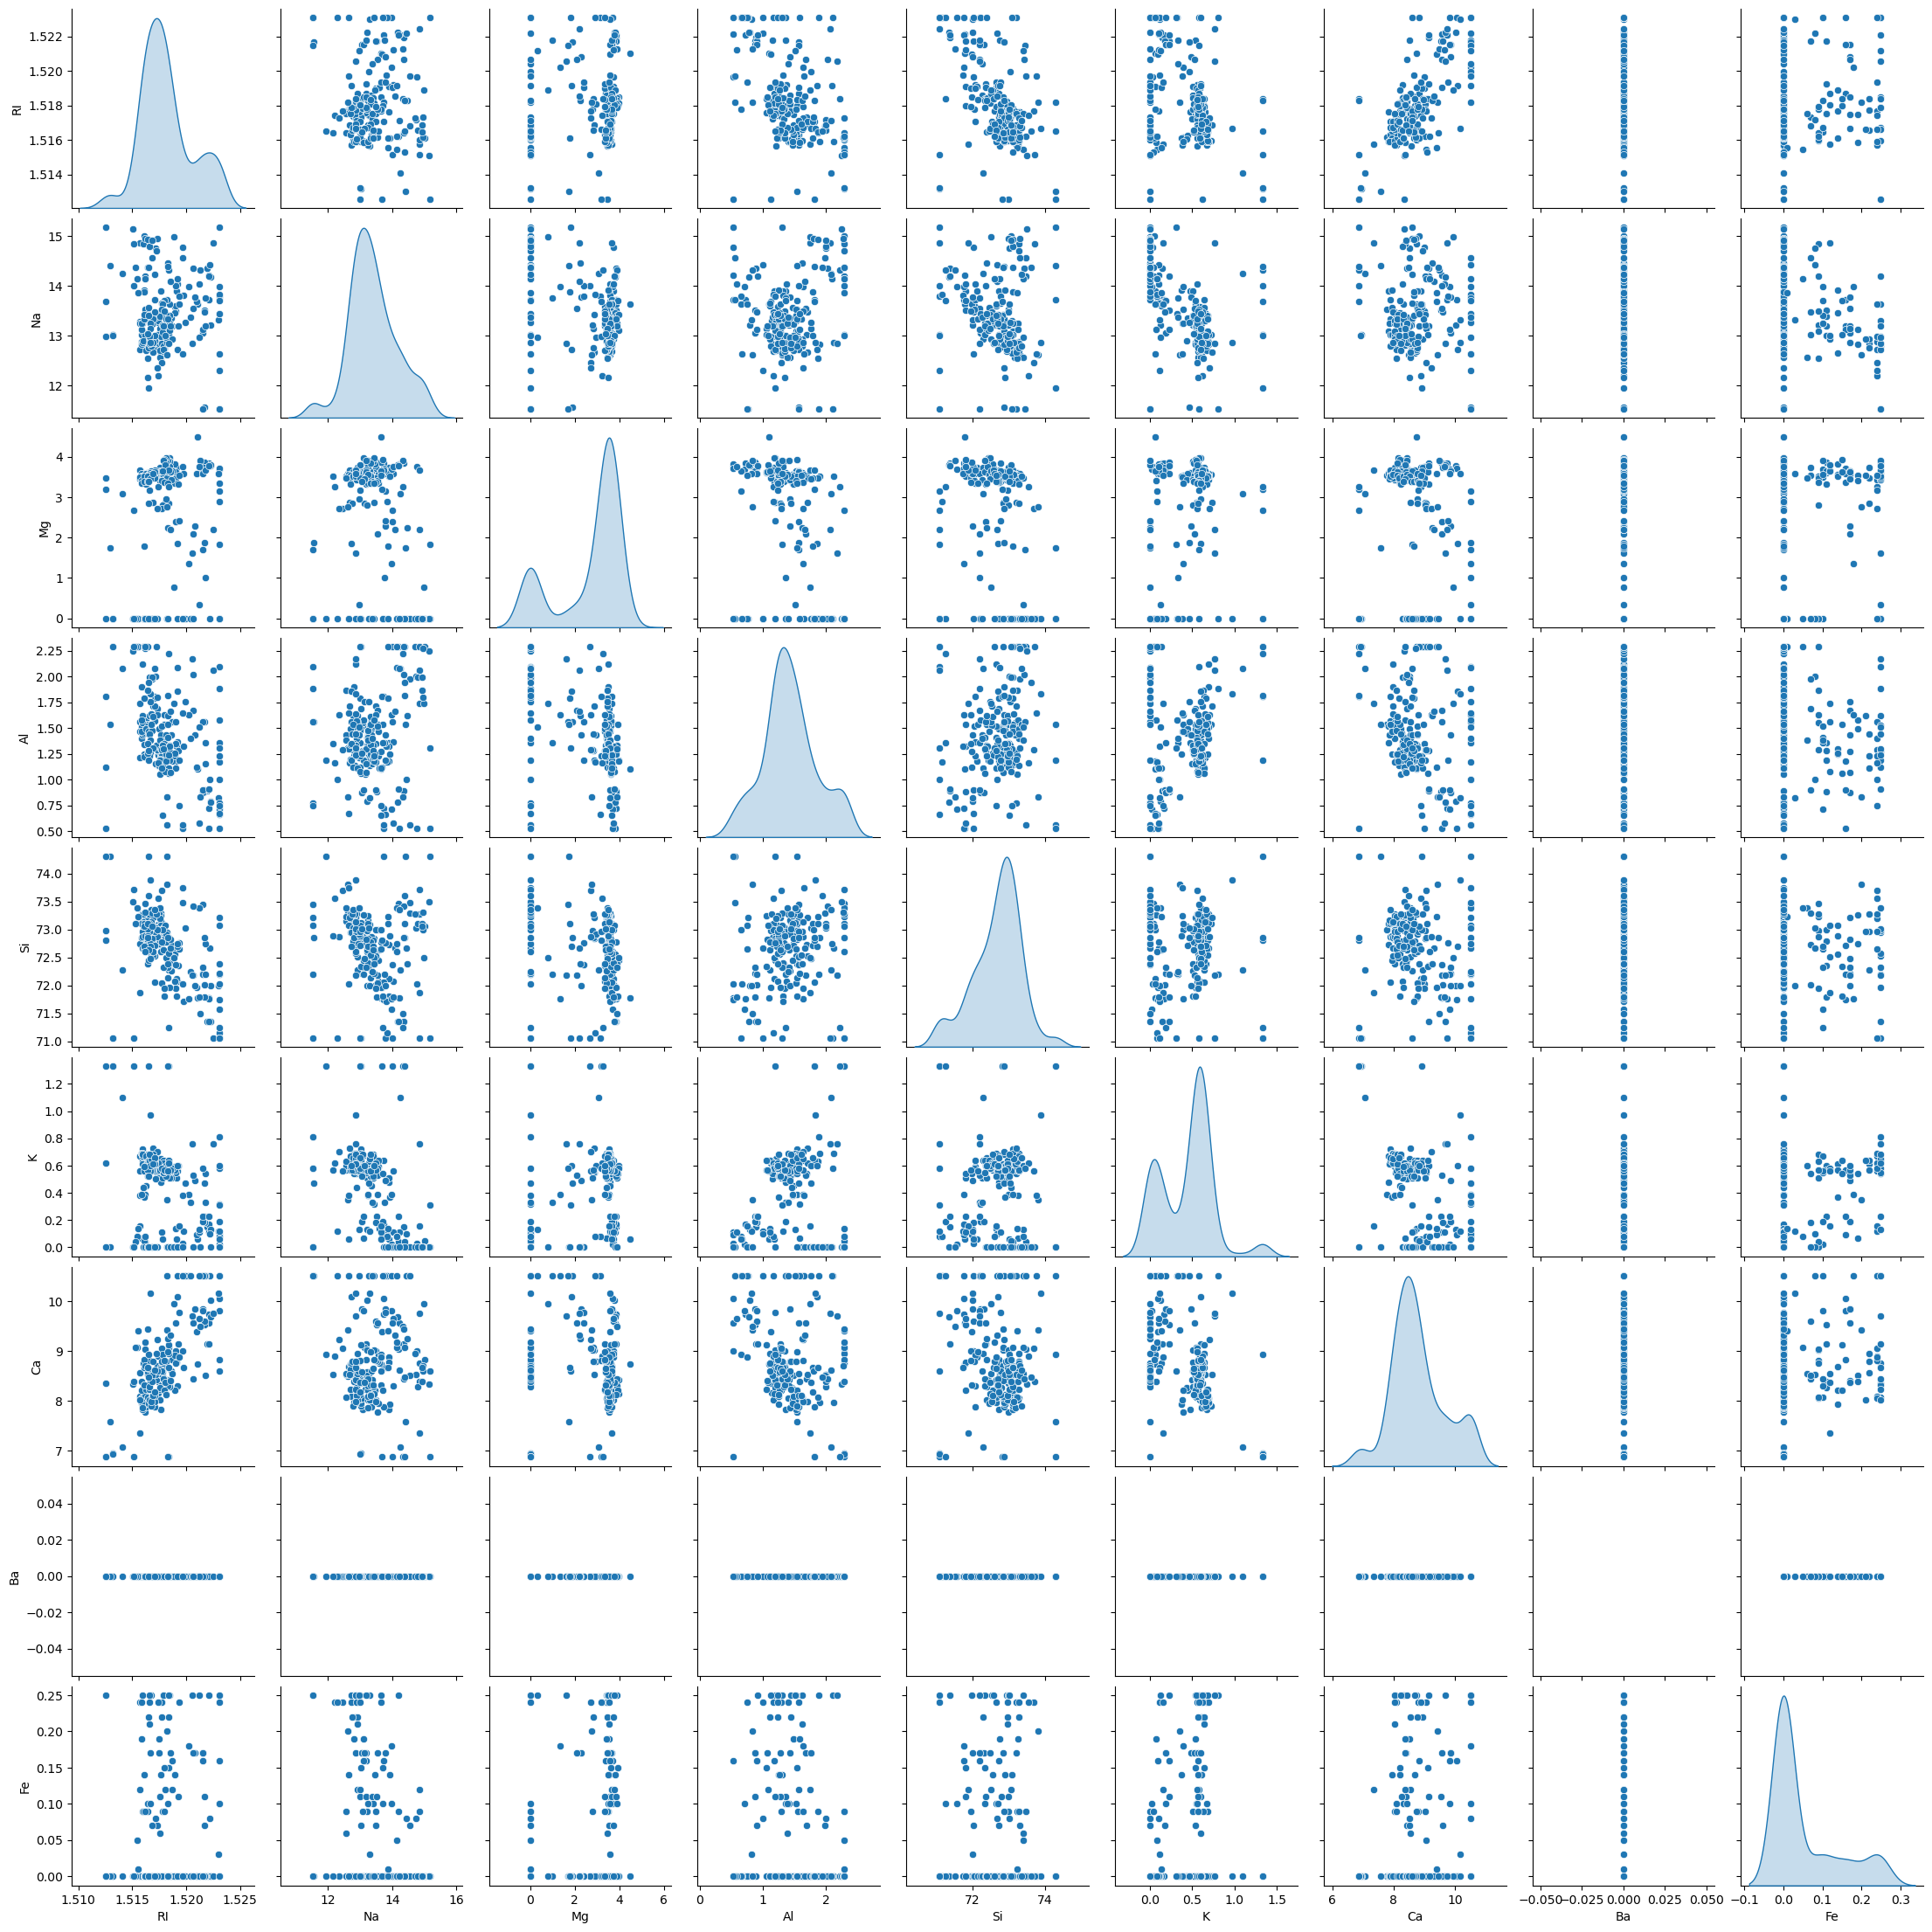

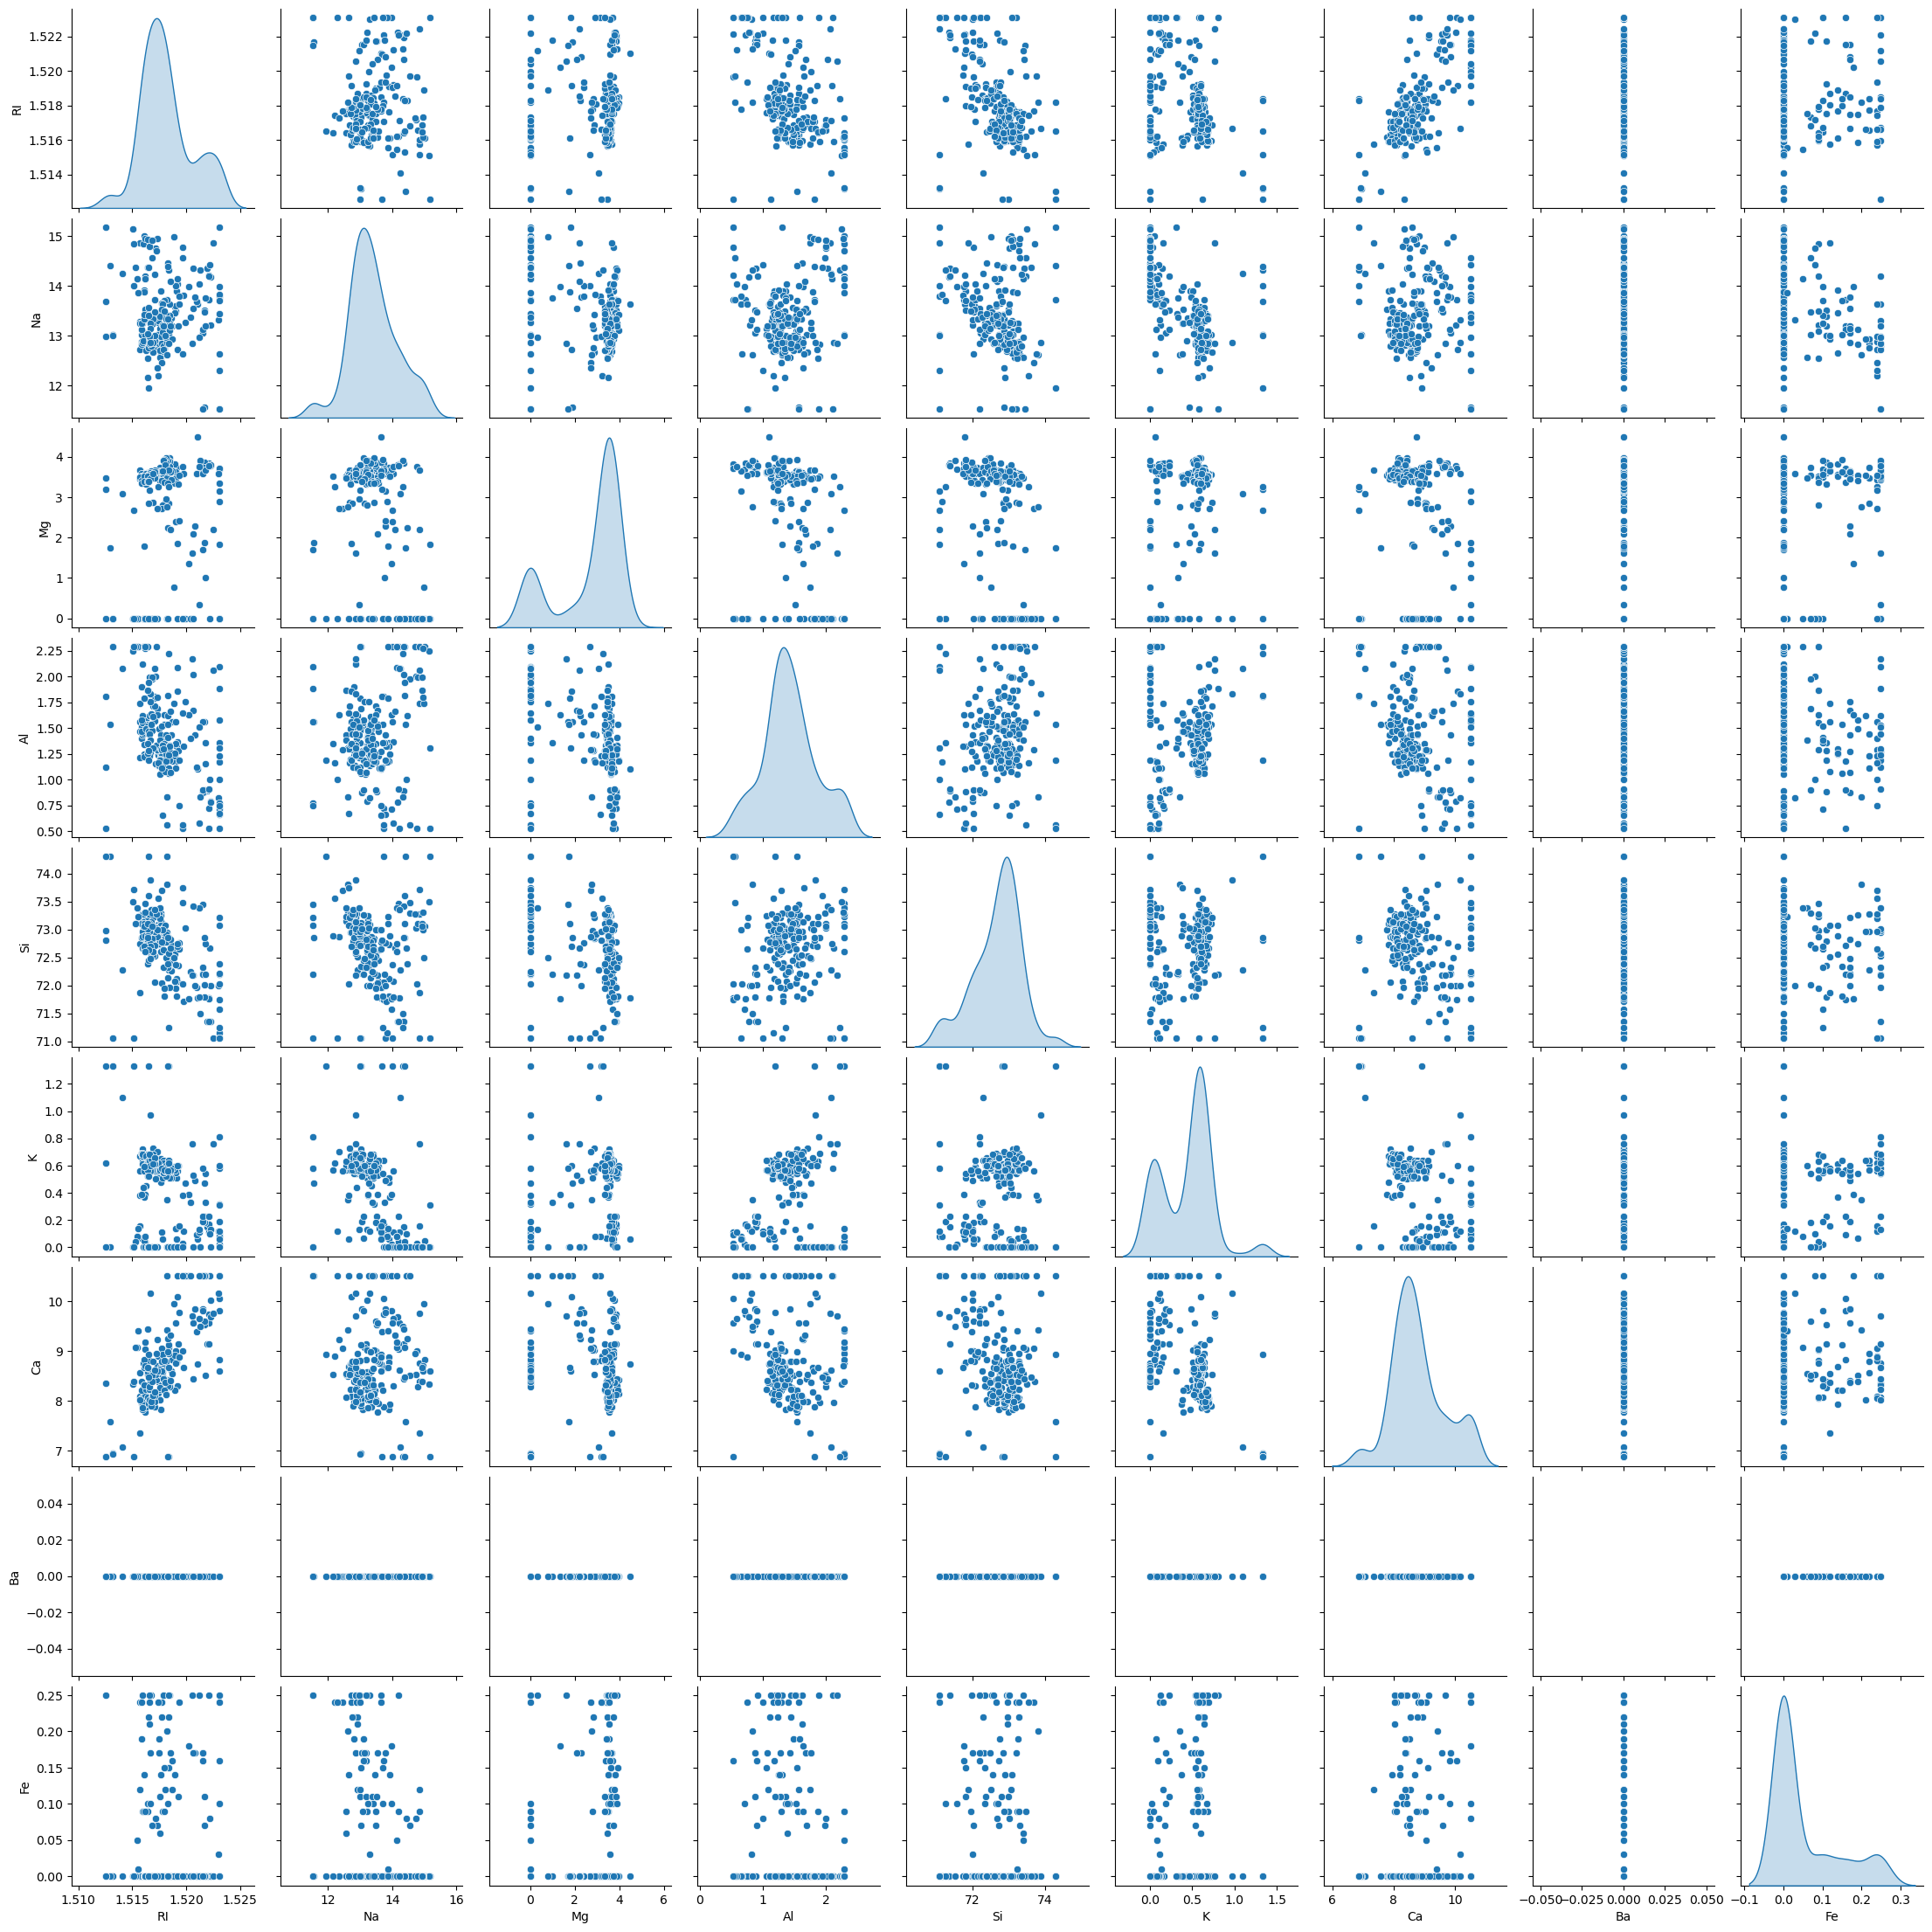

In [86]:
for col in features.columns:
    sns.pairplot(features,diag_kind='kde')
    plt.show()

In [87]:
df.corr()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
RI,1.000000,-0.072901,-0.038895,-0.461848,-0.526911,-0.339382,0.760626,NaN,0.100217,-0.155095
Na,-0.072901,1.000000,-0.300589,0.223172,-0.158794,-0.492717,-0.103610,NaN,-0.249138,0.503702
Mg,-0.038895,-0.300589,1.000000,-0.472330,-0.206544,0.334363,-0.372089,NaN,0.104381,-0.739870
Al,-0.461848,0.223172,-0.472330,1.000000,0.130631,0.173969,-0.277706,NaN,-0.096567,0.585616
Si,-0.526911,-0.158794,-0.206544,0.130631,1.000000,-0.040748,-0.188686,NaN,-0.068593,0.166276
K,-0.339382,-0.492717,0.334363,0.173969,-0.040748,1.000000,-0.497856,NaN,0.076522,-0.243427
Ca,0.760626,-0.103610,-0.372089,-0.277706,-0.188686,-0.497856,1.000000,NaN,0.106853,0.073455
Ba,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fe,0.100217,-0.249138,0.104381,-0.096567,-0.068593,0.076522,0.106853,NaN,1.000000,-0.219217
Type,-0.155095,0.503702,-0.739870,0.585616,0.166276,-0.243427,0.073455,NaN,-0.219217,1.000000


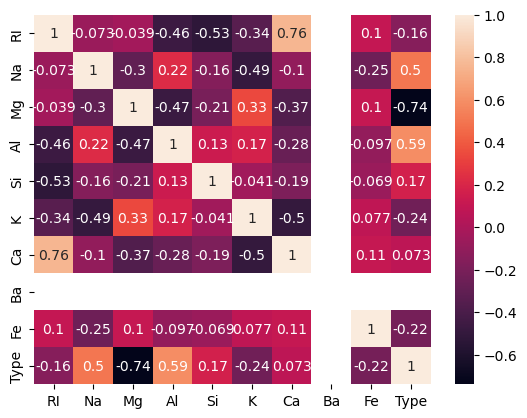

<Figure size 1000x2000 with 0 Axes>

In [94]:
corr = df.corr()
sns.heatmap(corr,annot=True)
plt.figure(figsize=(10,20))
plt.show()

In [97]:
## 1. 
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [99]:
## 2.
categ = df.select_dtypes('object').columns
categ

Index([], dtype='object')

In [160]:
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score,classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.ensemble import RandomForestClassifier

In [128]:
## 1. Divide the data into train and test split.
x_train,x_test,y_train,y_test = train_test_split(features,target,train_size=0.8,random_state=100)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(170, 9)
(43, 9)
(170,)
(43,)


In [129]:
x_train.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
183,1.51969,14.56,0.00,0.56,73.48,0.00,10.515,0.0,0.00
134,1.51811,13.33,3.85,1.25,72.78,0.52,8.120,0.0,0.00
32,1.51775,12.85,3.48,1.23,72.97,0.61,8.560,0.0,0.22
195,1.51545,14.14,0.00,2.29,73.39,0.08,9.070,0.0,0.05
26,1.51793,13.21,3.48,1.41,72.64,0.59,8.430,0.0,0.00


In [130]:
std_sca = StandardScaler()

In [131]:
## Apply feature scaling techniques such as standardization or normalization to ensure that all features are on a similar scale.
## Handling the imbalance data.
x_train[['RI','Na','Mg','Al','Si','K','Ca','Ba','Fe']] = std_sca.fit_transform(x_train[['RI','Na','Mg','Al','Si','K','Ca','Ba','Fe']])
x_train.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
183,0.741983,1.651085,-1.958518,-2.076295,1.230374,-1.470374,2.176407,0.0,-0.634094
134,0.040851,-0.105692,0.792410,-0.419271,0.140210,0.253056,-0.788161,0.0,-0.634094
32,-0.118900,-0.791264,0.528035,-0.467301,0.436111,0.551342,-0.243522,0.0,1.918662
195,-1.139534,1.051210,-1.958518,2.078273,1.090210,-1.205231,0.387764,0.0,-0.053922
26,-0.039024,-0.277085,0.528035,-0.035033,-0.077823,0.485056,-0.404438,0.0,-0.634094


In [132]:
x_test[['RI','Na','Mg','Al','Si','K','Ca','Ba','Fe']] = std_sca.transform(x_test[['RI','Na','Mg','Al','Si','K','Ca','Ba','Fe']])
x_test.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
116,0.120727,-0.234237,0.828136,-0.035033,-0.560610,0.352484,-0.552976,0.0,0.526250
42,-0.101150,-0.277085,0.463728,-0.227152,0.109062,0.485056,-0.206388,0.0,-0.634094
175,1.407614,-0.619871,-1.722724,0.205115,1.090210,-1.039517,2.176407,0.0,2.266765
84,-1.743040,1.208320,0.249370,1.573961,-0.638479,2.175343,-2.075489,0.0,-0.634094
112,2.252965,-1.091202,-1.958518,-1.812132,-1.043397,-1.271517,2.176407,0.0,-0.634094


In [133]:
## 2. Implement a Random Forest classifier using Python and a machine learning library like scikit-learn.

In [134]:
rand_fore = RandomForestClassifier(n_estimators=100,max_features='sqrt',bootstrap=True,max_samples=0.9,
                                 oob_score=True,random_state=50)
rand_fore.fit(x_train,y_train)
rand_fore.oob_score_

0.7764705882352941

In [135]:
y_pred = rand_fore.predict(x_test)
accuracy_score(y_test,y_pred)

0.6744186046511628

In [157]:
## 3. Train the model on the train dataset. Evaluate the performance on test data using metrics like accuracy, precision, recall, and F1-score.
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         1.0       0.67      1.00      0.80        10
         2.0       0.69      0.60      0.64        15
         3.0       0.50      0.25      0.33         4
         5.0       0.80      0.57      0.67         7
         6.0       0.62      0.71      0.67         7

    accuracy                           0.67        43
   macro avg       0.66      0.63      0.62        43
weighted avg       0.68      0.67      0.66        43



In [136]:
## Dropping columns RI and Si, because they have high VIF score, that means extremely high multicolllinearity
x_train1 = x_train.drop(columns=['RI','Si',])

In [137]:
x_train1.head()

,Na,Mg,Al,K,Ca,Ba,Fe
183,1.651085,-1.958518,-2.076295,-1.470374,2.176407,0.0,-0.634094
134,-0.105692,0.792410,-0.419271,0.253056,-0.788161,0.0,-0.634094
32,-0.791264,0.528035,-0.467301,0.551342,-0.243522,0.0,1.918662
195,1.051210,-1.958518,2.078273,-1.205231,0.387764,0.0,-0.053922
26,-0.277085,0.528035,-0.035033,0.485056,-0.404438,0.0,-0.634094


In [138]:
x_test1 = x_test.drop(columns=['RI','Si',])
x_test1.head()

,Na,Mg,Al,K,Ca,Ba,Fe
116,-0.234237,0.828136,-0.035033,0.352484,-0.552976,0.0,0.526250
42,-0.277085,0.463728,-0.227152,0.485056,-0.206388,0.0,-0.634094
175,-0.619871,-1.722724,0.205115,-1.039517,2.176407,0.0,2.266765
84,1.208320,0.249370,1.573961,2.175343,-2.075489,0.0,-0.634094
112,-1.091202,-1.958518,-1.812132,-1.271517,2.176407,0.0,-0.634094


In [146]:
rand_for = RandomForestClassifier(n_estimators=100,max_features='sqrt',bootstrap=True,max_samples=0.9,
                                 oob_score=True,random_state=50)
rand_for.fit(x_train1,y_train)
rand_for.oob_score_

0.7294117647058823

In [147]:
y_pred1 = rand_for.predict(x_test1)
accuracy_score(y_test,y_pred1)

0.6744186046511628

In [158]:
print(classification_report(y_test,y_pred1))

              precision    recall  f1-score   support

         1.0       0.53      0.90      0.67        10
         2.0       0.71      0.67      0.69        15
         3.0       0.00      0.00      0.00         4
         5.0       1.00      0.57      0.73         7
         6.0       0.75      0.86      0.80         7

    accuracy                           0.67        43
   macro avg       0.60      0.60      0.58        43
weighted avg       0.66      0.67      0.64        43



In [150]:
## Dropping the Ba column, because that column have no impact on target.
x_train2 = x_train.drop(columns=['Ba'])
x_test2 = x_test.drop(columns=['Ba'])

In [151]:
x_train2.head()

,RI,Na,Mg,Al,Si,K,Ca,Fe
183,0.741983,1.651085,-1.958518,-2.076295,1.230374,-1.470374,2.176407,-0.634094
134,0.040851,-0.105692,0.792410,-0.419271,0.140210,0.253056,-0.788161,-0.634094
32,-0.118900,-0.791264,0.528035,-0.467301,0.436111,0.551342,-0.243522,1.918662
195,-1.139534,1.051210,-1.958518,2.078273,1.090210,-1.205231,0.387764,-0.053922
26,-0.039024,-0.277085,0.528035,-0.035033,-0.077823,0.485056,-0.404438,-0.634094


In [152]:
x_test2.head()

,RI,Na,Mg,Al,Si,K,Ca,Fe
116,0.120727,-0.234237,0.828136,-0.035033,-0.560610,0.352484,-0.552976,0.526250
42,-0.101150,-0.277085,0.463728,-0.227152,0.109062,0.485056,-0.206388,-0.634094
175,1.407614,-0.619871,-1.722724,0.205115,1.090210,-1.039517,2.176407,2.266765
84,-1.743040,1.208320,0.249370,1.573961,-0.638479,2.175343,-2.075489,-0.634094
112,2.252965,-1.091202,-1.958518,-1.812132,-1.043397,-1.271517,2.176407,-0.634094


In [154]:
rand_fore1 = RandomForestClassifier(n_estimators=100,max_features='sqrt',bootstrap=True,max_samples=0.9,
                                 oob_score=True,random_state=50)
rand_fore1.fit(x_train2,y_train)
rand_fore1.oob_score_

0.7705882352941177

In [188]:
y_pred2 = rand_fore1.predict(x_test2)
acc1 =accuracy_score(y_test,y_pred2)
print(acc1)

0.7441860465116279


In [159]:
print(classification_report(y_test,y_pred2))

              precision    recall  f1-score   support

         1.0       0.67      1.00      0.80        10
         2.0       0.79      0.73      0.76        15
         3.0       0.50      0.25      0.33         4
         5.0       1.00      0.57      0.73         7
         6.0       0.75      0.86      0.80         7

    accuracy                           0.74        43
   macro avg       0.74      0.68      0.68        43
weighted avg       0.76      0.74      0.73        43



In [161]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid.fit(x_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
0.8117647058823529


In [169]:
y_pred0 = grid.predict(x_test)
accuracy_score(y_test,y_pred0)

0.6511627906976745

## Bagging

In [167]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier

In [189]:
bagging = BaggingClassifier(estimator = LogisticRegression(),n_estimators = 10, max_samples=0.9,
                           max_features =1.0,bootstrap=True,bootstrap_features=False,
                            random_state=50,oob_score=True)
bagging.fit(x_train,y_train)
y_pred3 =bagging.predict(x_test)
acc2 =accuracy_score(y_test,y_pred3)
acc2

0.6511627906976745

In [172]:
bagging.oob_score_

0.6294117647058823

## Boosting

In [ ]:
## I use XGBM booster here. for that i need to enocde target. because the XGBM uses continuous variable as target

In [177]:
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

In [178]:
lab_enc = LabelEncoder()

y_train_enc = lab_enc.fit_transform(y_train)
y_test_enc = lab_enc.transform(y_test)

In [190]:
xg_boost = xgb.XGBClassifier(n_estimators=100,learning_rate=0.5,min_child_weight=2,subsample=0.9,reg_alpha=10,reg_lambda=10,random_state=50)
xg_boost.fit(x_train, y_train_enc)
y_pred4 = xg_boost.predict(x_test)
acc3 = accuracy_score(y_test_enc, y_pred4)
acc3

0.627906976744186

In [192]:
dict1 = {'Methods':['Random Forest','Bagging','Boosting'],'Accuracy Score':[acc1,acc2,acc3]}
comp = pd.DataFrame(dict1)
comp

,Methods,Accuracy Score
0,Random Forest,0.744186
1,Bagging,0.651163
2,Boosting,0.627907
